In [1]:
## Imports + paths
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from scipy.optimize import brentq
import sys
import sys
sys.path.append('./src')
DATA_DIR  = Path('/mnt/nasquatch/data/RNAseq/allenV1_SMART-seq')
CACHE_DIR = DATA_DIR / 'cache'
SRC_DIR   = Path('/mnt/nasquatch/data/analysis/josh/allen-scRNAseq-analysis/src')
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

sc.settings.verbosity = 1
plt.rcParams['figure.dpi'] = 120

def read_parquet(path):
    return pq.read_table(path).to_pandas()

In [2]:
## Load adata_l23_inh (Tasic L2/3 GABAergic cells)
import data_loader as data_loader

SUPERFICIAL_LAYERS = ['L1', 'L1-L2/3', 'L1-L4', 'L1-L6', 'L2/3', 'L2/3-L4', 'L4']
EXCLUDE_SUBCLASSES = {'Serpinf1', 'Meis2'}

adata_l23_inh = data_loader.load_allen_filtered(
    metadata_path=str(DATA_DIR / 'mouse_VISp_2018-06-14_samples-columns.csv'),
    expression_path=str(DATA_DIR / 'mouse_VISp_2018-06-14_exon-matrix.csv'),
    target_class='GABAergic',
    target_layers=SUPERFICIAL_LAYERS,
    genes_path=str(DATA_DIR / 'mouse_VISp_2018-06-14_genes-rows.csv'),
    layer_name='counts',
    obsm_paths={'X_umap': str(CACHE_DIR / 'umap_gaba.csv')},
)

keep = ~adata_l23_inh.obs['subclass'].isin(EXCLUDE_SUBCLASSES)
adata_l23_inh = adata_l23_inh[keep].copy()

print(f'adata_l23_inh: {adata_l23_inh.n_obs} cells x {adata_l23_inh.n_vars} genes')
print('Subclass breakdown:')
print(adata_l23_inh.obs['subclass'].value_counts().to_string())

Loading metadata from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_samples-columns.csv...
Loaded metadata: 15413 cells × 49 columns
Key columns: ['class', 'subclass', 'cluster']
Metadata filter: 3215 of 15413 cells selected (class='GABAergic', layers=['L1', 'L1-L2/3', 'L1-L4', 'L1-L6', 'L2/3', 'L2/3-L4', 'L4'])
Loading expression matrix from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_exon-matrix.csv...
  Reading 3215 of 15413 cell columns...
Loaded expression: 3215 cells × 45768 genes
Creating AnnData with 3215 cells

Cell classes: 1
class
GABAergic    3215
Name: count, dtype: int64
Loading obsm embeddings...
  obsm['X_umap']: loaded shape (3215, 2)
adata_l23_inh: 3202 cells x 45768 genes
Subclass breakdown:
subclass
Vip      1327
Lamp5     981
Pvalb     513
Sst       315
Sncg       66


In [3]:
## Load MET reference centroids + ground-truth labels
#
# met_ref: Tasic median log1p(CPM) centroids per MET type (from met_reference.ipynb)
# gt_labels: per-cell MET assignments from the marker-gene two-step in met_reference.ipynb

SUBCLASS_ORDER = ['Pvalb', 'Sst', 'Vip', 'Lamp5', 'Sncg']

met_ref = read_parquet(CACHE_DIR / 'tasic_met_centroids.parquet')
print(f'MET reference: {met_ref.shape[0]} types x {met_ref.shape[1]:,} genes')

gt_labels = pd.read_csv(CACHE_DIR / 'tasic_met_assignments.csv', index_col=0)
print(f'Ground-truth labels: {len(gt_labels)} cells')

# Sort MET type list by subclass order, then numeric MET index
met_names = list(met_ref.index)
met_idx   = {m: i for i, m in enumerate(met_names)}

subclass_to_mets = {
    sc: sorted(
        [m for m in met_names if m.startswith(sc + '-')],
        key=lambda x: int(x.split('-MET-')[1])
    )
    for sc in SUBCLASS_ORDER
}
MET_ORDER = [m for sc in SUBCLASS_ORDER for m in subclass_to_mets[sc]]

print('\nMET types per subclass:')
for sc, mets in subclass_to_mets.items():
    print(f'  {sc}: {mets}')

print('\nGround-truth MET-type distribution:')
gt_counts = gt_labels['met_type_pred_markers'].value_counts().reset_index()
gt_counts.columns = ['MET-type', 'n']
gt_counts['sc'] = gt_counts['MET-type'].str.split('-').str[0]
gt_counts['num'] = gt_counts['MET-type'].str.extract(r'MET-(\d+)').astype(int)
gt_counts['order'] = gt_counts['sc'].map({s: i for i, s in enumerate(SUBCLASS_ORDER)})
gt_counts = gt_counts.sort_values(['order', 'num'])
print(gt_counts[['MET-type', 'n']].to_string(index=False))

MET reference: 12 types x 45,768 genes
Ground-truth labels: 3202 cells

MET types per subclass:
  Pvalb: ['Pvalb-MET-4', 'Pvalb-MET-5']
  Sst: ['Sst-MET-1', 'Sst-MET-2', 'Sst-MET-3', 'Sst-MET-8']
  Vip: ['Vip-MET-1', 'Vip-MET-2', 'Vip-MET-4', 'Vip-MET-5']
  Lamp5: ['Lamp5-MET-1']
  Sncg: ['Sncg-MET-1']

Ground-truth MET-type distribution:
   MET-type   n
Pvalb-MET-4 471
Pvalb-MET-5  42
  Sst-MET-1  17
  Sst-MET-2 160
  Sst-MET-3  99
  Sst-MET-8  39
  Vip-MET-1 412
  Vip-MET-2 448
  Vip-MET-4  50
  Vip-MET-5 417
Lamp5-MET-1 981
 Sncg-MET-1  66


In [4]:
## Build shared gene space + log1p(CPM) matrices

# Map gene symbols to Entrez IDs (Tasic var index)
sym_to_entrez = pd.Series(adata_l23_inh.var_names, index=adata_l23_inh.var['gene_symbol'])
sym_to_entrez = sym_to_entrez[~sym_to_entrez.index.duplicated(keep='first')]

shared_genes   = sorted(set(met_ref.columns) & set(sym_to_entrez.index))
shared_entrez  = sym_to_entrez[shared_genes].values
shared_col_idx = [adata_l23_inh.var_names.get_loc(e) for e in shared_entrez]
shared_gene_pos = {g: i for i, g in enumerate(shared_genes)}

print(f'Shared genes: {len(shared_genes):,}  '
      f'(met_ref: {met_ref.shape[1]:,} / Tasic: {len(sym_to_entrez):,})')

# Tasic: raw counts -> log1p(CPM) on shared genes
X_dense = adata_l23_inh.layers['counts']
if hasattr(X_dense, 'toarray'):
    X_dense = X_dense.toarray()
cell_total = X_dense.sum(axis=1, keepdims=True)
X_log = np.log1p(X_dense[:, shared_col_idx] / cell_total * 1e6)

# MET reference: already log1p(CPM) from centroids
ref_log = np.log1p(met_ref[shared_genes].values)

print(f'X_log shape  : {X_log.shape}')
print(f'ref_log shape: {ref_log.shape}')

Shared genes: 45,768  (met_ref: 45,768 / Tasic: 45,768)
X_log shape  : (3202, 45768)
ref_log shape: (12, 45768)


In [5]:
## GMM binarization thresholds for cardinal subclass genes

CARDINAL_GENES = ['Pvalb', 'Sst', 'Vip', 'Lamp5', 'Sncg']
THRESHOLD_PROB = 0.95

gmm_thresholds = {}
gmm_models     = {}

for gene in CARDINAL_GENES:
    if gene not in shared_gene_pos:
        print(f'WARNING: {gene} not in shared genes')
        continue
    log_expr = X_log[:, shared_gene_pos[gene]]
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(log_expr.reshape(-1, 1))
    order  = np.argsort(gmm.means_.ravel())
    hi_idx = int(order[1])

    def _find_threshold(prob, _gmm=gmm, _hi=hi_idx, _max=float(log_expr.max())):
        def score(x):
            return _gmm.predict_proba([[x]])[0][_hi] - prob
        try:
            return brentq(score, 0.0, _max + 2.0)
        except ValueError:
            return np.nan

    t = _find_threshold(THRESHOLD_PROB)
    gmm_thresholds[gene] = t
    gmm_models[gene]     = gmm
    pct = (log_expr > t).mean() * 100
    print(f'{gene:<8s}: threshold={t:.2f}  {pct:.1f}% cells positive')

Pvalb   : threshold=0.01  30.0% cells positive
Sst     : threshold=2.03  9.7% cells positive
Vip     : threshold=6.24  39.6% cells positive
Lamp5   : threshold=1.40  31.8% cells positive
Sncg    : threshold=0.01  3.7% cells positive


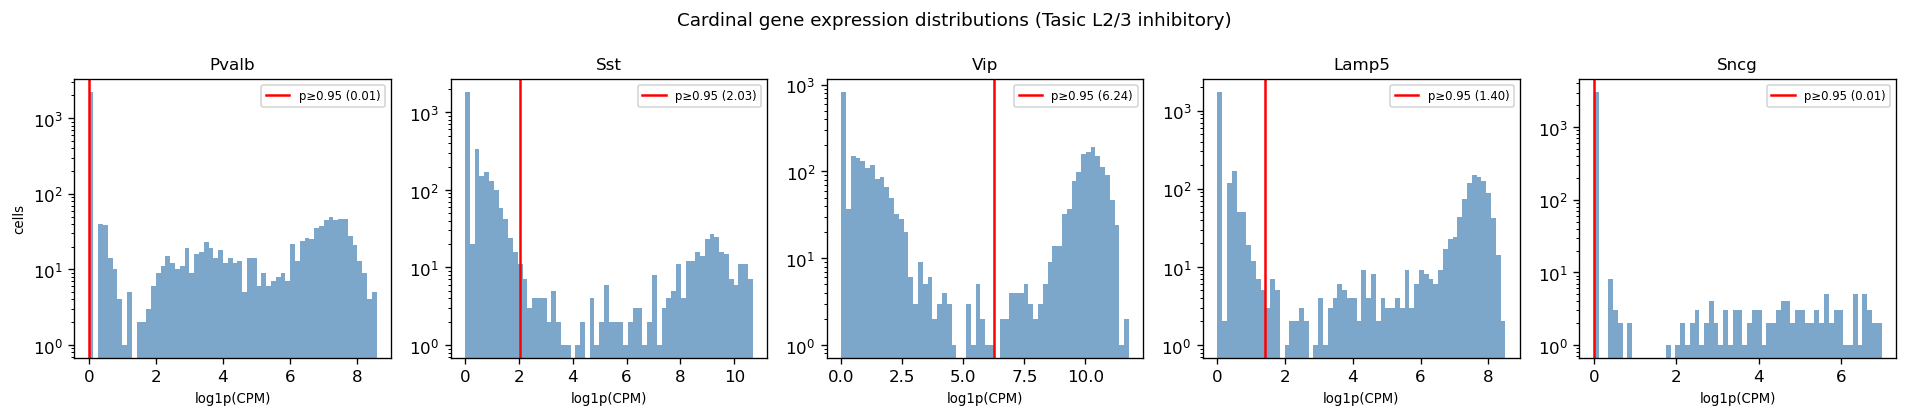

In [6]:
## Cardinal gene expression distributions with GMM thresholds

fig, axes = plt.subplots(1, len(CARDINAL_GENES), figsize=(16, 3.5))
for ax, gene in zip(axes, CARDINAL_GENES):
    if gene not in shared_gene_pos:
        continue
    expr = X_log[:, shared_gene_pos[gene]]
    ax.hist(expr, bins=60, color='steelblue', alpha=0.7, edgecolor='none')
    t = gmm_thresholds.get(gene, np.nan)
    if not np.isnan(t):
        ax.axvline(t, color='red', lw=1.5, label=f'p≥{THRESHOLD_PROB} ({t:.2f})')
        ax.legend(fontsize=7)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel('log1p(CPM)', fontsize=8)
    ax.set_yscale('log')
axes[0].set_ylabel('cells', fontsize=8)
plt.suptitle('Cardinal gene expression distributions (Tasic L2/3 inhibitory)', fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
## Two-step classification helpers

def binarize_expression(log_X_cols, gene_list, thresholds):
    """Threshold log-count columns to binary 0/1 via per-gene GMM thresholds."""
    binary = np.zeros(log_X_cols.shape, dtype=np.float32)
    for j, gene in enumerate(gene_list):
        t = thresholds.get(gene, np.nan)
        if not np.isnan(t):
            binary[:, j] = (log_X_cols[:, j] > t).astype(np.float32)
    return binary


def assign_cardinal_class(log_X_all, cardinal_genes, thresholds, shared_gene_pos):
    """
    Step 1: binarize cardinal marker expression and assign each cell to a
    cardinal subclass. Sncg is given priority over Vip when both are positive.
    Cells with no gene above threshold fall back to argmax over log expression.
    """
    c_found = [g for g in cardinal_genes if g in shared_gene_pos]
    c_cols  = [shared_gene_pos[g] for g in c_found]
    log_Xc  = log_X_all[:, c_cols]
    binary  = binarize_expression(log_Xc, c_found, thresholds)

    sncg_j = c_found.index('Sncg') if 'Sncg' in c_found else -1
    n_cells = log_X_all.shape[0]
    pred_class = np.empty(n_cells, dtype=object)

    for i in range(n_cells):
        b = binary[i]
        if sncg_j >= 0 and b[sncg_j] > 0:
            pred_class[i] = 'Sncg'
        elif b.sum() > 0:
            cands = np.where(b == b.max())[0]
            best  = cands[np.argmax(log_Xc[i, cands])]
            pred_class[i] = c_found[best]
        else:
            # No gene clears the GMM threshold — fall back to argmax over expression
            pred_class[i] = c_found[np.argmax(log_Xc[i])]
    return pred_class


def assign_met_type(
    X_query_log,
    ref_log_all,
    pred_class,
    subclass_to_mets,
    met_idx,
    gene_cols=None,
):
    """
    Step 2: within each cardinal class, assign to the nearest MET centroid by
    cosine similarity. `gene_cols` selects a subset of columns from both
    X_query_log and ref_log_all (default: all columns = full transcriptome).
    """
    n_cells = X_query_log.shape[0]
    pred    = np.full(n_cells, 'Unknown', dtype=object)

    for sc, mets in subclass_to_mets.items():
        if not mets:
            continue
        mask = pred_class == sc
        if not mask.any():
            continue
        ref_rows = [met_idx[m] for m in mets]
        if gene_cols is not None:
            X_sc   = X_query_log[mask][:, gene_cols]
            ref_sc = ref_log_all[ref_rows][:, gene_cols]
        else:
            X_sc   = X_query_log[mask]
            ref_sc = ref_log_all[ref_rows]
        sim  = cos_sim(X_sc, ref_sc)
        pred[mask] = [mets[i] for i in sim.argmax(axis=1)]

    return pred

In [8]:
## Step 1: GMM cardinal class assignment

pred_class = assign_cardinal_class(X_log, CARDINAL_GENES, gmm_thresholds, shared_gene_pos)

true_subclass  = adata_l23_inh.obs['subclass'].values.astype(str)
cluster_labels = adata_l23_inh.obs['cluster'].values.astype(str)

valid = true_subclass != 'Unknown'
class_acc = (pred_class[valid] == true_subclass[valid]).mean()
print(f'Step 1 cardinal class accuracy (vs Allen annotation): {class_acc:.3f}')

conf_class = pd.crosstab(
    pd.Categorical(true_subclass[valid], categories=SUBCLASS_ORDER + ['Unknown']),
    pd.Categorical(pred_class[valid],    categories=SUBCLASS_ORDER + ['Unknown']),
)
print('\nConfusion (rows=true, cols=predicted):')
print(conf_class)

Step 1 cardinal class accuracy (vs Allen annotation): 0.940

Confusion (rows=true, cols=predicted):
col_0  Pvalb  Sst   Vip  Lamp5  Sncg
row_0                               
Pvalb    509    1     1      0     2
Sst       44  259     7      0     5
Vip       15   23  1258      8    23
Lamp5      5    2    10    929    35
Sncg       0    0    11      0    55


In [9]:
## Step 2 (baseline): full shared transcriptome cosine similarity

pred_met_baseline = assign_met_type(
    X_log, ref_log, pred_class,
    subclass_to_mets, met_idx,
    gene_cols=None,  # all shared genes
)

print('Baseline MET-type assignment (full shared transcriptome):')
pred_counts = pd.Series(pred_met_baseline).value_counts().reset_index()
pred_counts.columns = ['MET-type', 'n_cells']
pred_counts['order'] = pred_counts['MET-type'].map(
    {m: i for i, m in enumerate(MET_ORDER)}
).fillna(999)
pred_counts = pred_counts.sort_values('order')
print(pred_counts[['MET-type', 'n_cells']].to_string(index=False))

Baseline MET-type assignment (full shared transcriptome):
   MET-type  n_cells
Pvalb-MET-4      519
Pvalb-MET-5       54
  Sst-MET-1       14
  Sst-MET-2       97
  Sst-MET-3      116
  Sst-MET-8       58
  Vip-MET-1      299
  Vip-MET-2      400
  Vip-MET-4      299
  Vip-MET-5      289
Lamp5-MET-1      937
 Sncg-MET-1      120


In [10]:
## Accuracy vs ground-truth MET labels from met_reference.ipynb

# Align ground-truth to adata_l23_inh cell order
gt_aligned = gt_labels.reindex(adata_l23_inh.obs_names)['met_type_pred_markers'].values
valid_gt   = np.array([g in MET_ORDER for g in gt_aligned], dtype=bool)

overall_acc = (pred_met_baseline[valid_gt] == gt_aligned[valid_gt]).mean()
n_match     = (pred_met_baseline[valid_gt] == gt_aligned[valid_gt]).sum()
print(f'Baseline accuracy vs ground truth: {overall_acc:.3f}  ({n_match} / {valid_gt.sum()} cells)')

print('\nPer-subclass accuracy:')
for sc in SUBCLASS_ORDER:
    sc_mask = (true_subclass == sc) & valid_gt
    if sc_mask.any():
        sc_acc = (pred_met_baseline[sc_mask] == gt_aligned[sc_mask]).mean()
        print(f'  {sc:<8s}: {sc_acc:.3f}  ({sc_mask.sum()} cells)')

Baseline accuracy vs ground truth: 0.787  (2519 / 3202 cells)

Per-subclass accuracy:
  Pvalb   : 0.986  (513 cells)
  Sst     : 0.648  (315 cells)
  Vip     : 0.622  (1327 cells)
  Lamp5   : 0.947  (981 cells)
  Sncg    : 0.833  (66 cells)


In [11]:
## Build varibow color maps (shared across all visualization cells)

import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from visualization import varibow

# T-type cluster order grouped by subclass (drop clusters with <10 cells)
obs_cl = adata_l23_inh.obs[['subclass', 'cluster']].copy()
valid_clusters = obs_cl['cluster'].value_counts()
valid_clusters = valid_clusters[valid_clusters >= 10].index
obs_cl = obs_cl[obs_cl['cluster'].isin(valid_clusters)]

subclass_order_cl   = obs_cl['subclass'].value_counts().index.tolist()
cluster_to_subclass = obs_cl.groupby('cluster')['subclass'].first()
cluster_order = []
for sc in subclass_order_cl:
    cluster_order.extend(
        obs_cl.loc[obs_cl['subclass'] == sc, 'cluster'].value_counts().index.tolist()
    )

palette_cl    = varibow(len(cluster_order))
cluster_color = {c: palette_cl[i] for i, c in enumerate(cluster_order)}

# Slice of varibow palette assigned to each subclass
sc_palette_range = {}
i = 0
for sc in subclass_order_cl:
    n = sum(1 for c in cluster_order if cluster_to_subclass[c] == sc)
    sc_palette_range[sc] = np.array(palette_cl[i:i + n])
    i += n

# MET-type colors: interpolate within each subclass hue band
met_color = {}
for sc in SUBCLASS_ORDER:
    mets = subclass_to_mets[sc]
    if not mets or sc not in sc_palette_range or len(sc_palette_range[sc]) == 0:
        for m in mets:
            met_color[m] = np.array([0.5, 0.5, 0.5])
        continue
    sc_colors = sc_palette_range[sc]
    cmap = LinearSegmentedColormap.from_list('', sc_colors)
    positions = [0.5] if len(mets) == 1 else np.linspace(0, 1, len(mets))
    for m, pos in zip(mets, positions):
        met_color[m] = np.array(cmap(pos)[:3])

# Tick colors and subclass boundaries for confusion matrices
met_to_subclass = {m: m.split('-')[0] for m in MET_ORDER}
tick_colors     = [met_color[m] for m in MET_ORDER]
sc_sizes        = [len(subclass_to_mets[sc]) for sc in SUBCLASS_ORDER]
boundaries      = list(np.cumsum(sc_sizes)[:-1])

print(f'Varibow palette: {len(cluster_order)} clusters, {len(met_color)} MET types')

Varibow palette: 36 clusters, 12 MET types


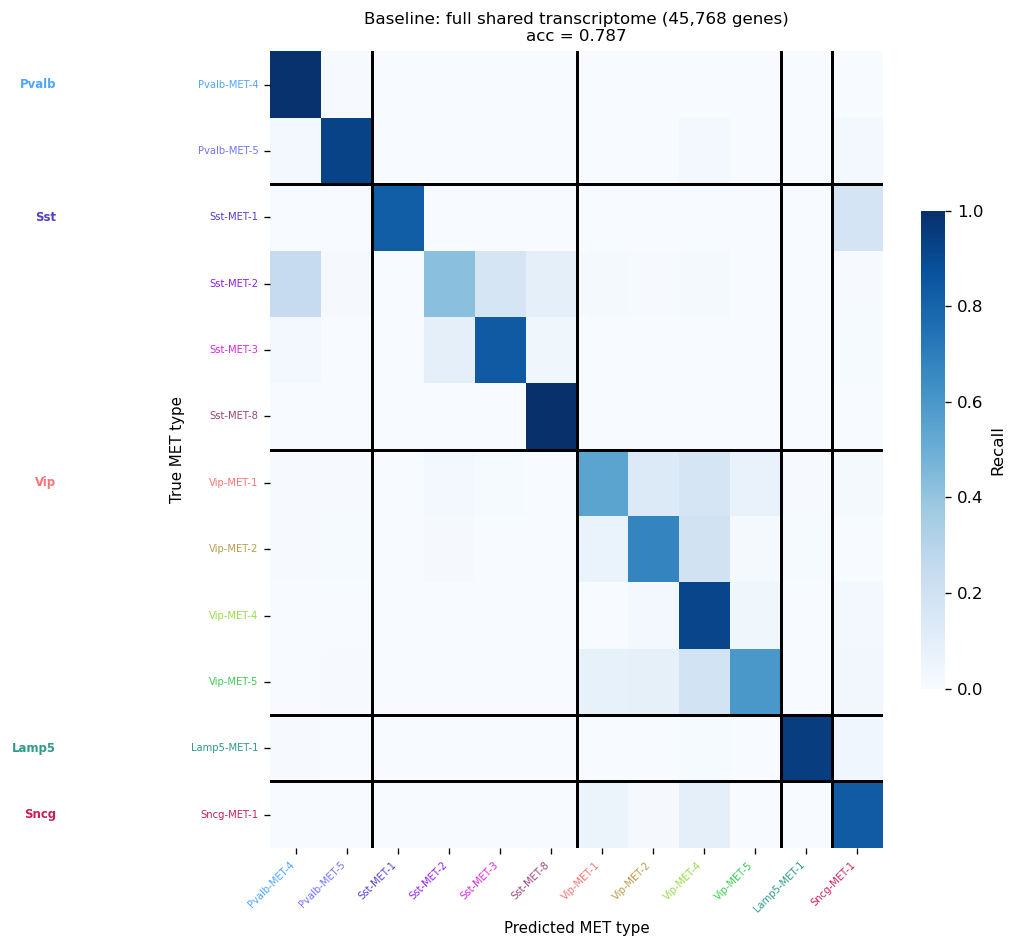

In [12]:
## Confusion matrix: baseline full-transcriptome vs ground truth

def draw_met_conf_heatmap(ax, conf_norm, title, met_order=MET_ORDER, show_ylabel=True, show_cbar=True):
    """Row-normalised recall heatmap for MET-type confusion."""
    sns.heatmap(
        conf_norm.values,
        ax=ax, cmap='Blues', vmin=0, vmax=1,
        linewidths=0,
        xticklabels=met_order,
        yticklabels=met_order if show_ylabel else [],
        cbar=show_cbar,
        cbar_kws={'label': 'Recall', 'shrink': 0.6} if show_cbar else {},
    )
    for b in boundaries:
        ax.axhline(b, color='black', linewidth=1.8)
        ax.axvline(b, color='black', linewidth=1.8)

    for tick, col in zip(ax.get_xticklabels(), tick_colors):
        tick.set_color(col); tick.set_fontsize(6)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    if show_ylabel:
        for tick, col in zip(ax.get_yticklabels(), tick_colors):
            tick.set_color(col); tick.set_fontsize(6)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

        prev_sc = None
        for i, m in enumerate(met_order):
            sc = met_to_subclass[m]
            if sc != prev_sc:
                ax.text(-0.35, i + 0.5, sc, ha='right', va='center', fontsize=7,
                        fontweight='bold', color=met_color[m],
                        transform=ax.get_yaxis_transform())
                prev_sc = sc

    ax.set_xlabel('Predicted MET type', fontsize=9)
    ax.set_ylabel('True MET type' if show_ylabel else '', fontsize=9)
    ax.set_title(title, fontsize=10)


conf = pd.DataFrame(0, index=MET_ORDER, columns=MET_ORDER)
for t, p in zip(gt_aligned, pred_met_baseline):
    if t in conf.index and p in conf.columns:
        conf.loc[t, p] += 1
conf_norm = conf.div(conf.sum(axis=1).replace(0, 1), axis=0)

fig, ax = plt.subplots(figsize=(9, 8))
draw_met_conf_heatmap(
    ax, conf_norm,
    f'Baseline: full shared transcriptome ({len(shared_genes):,} genes)\nacc = {overall_acc:.3f}',
)
plt.tight_layout()
plt.show()

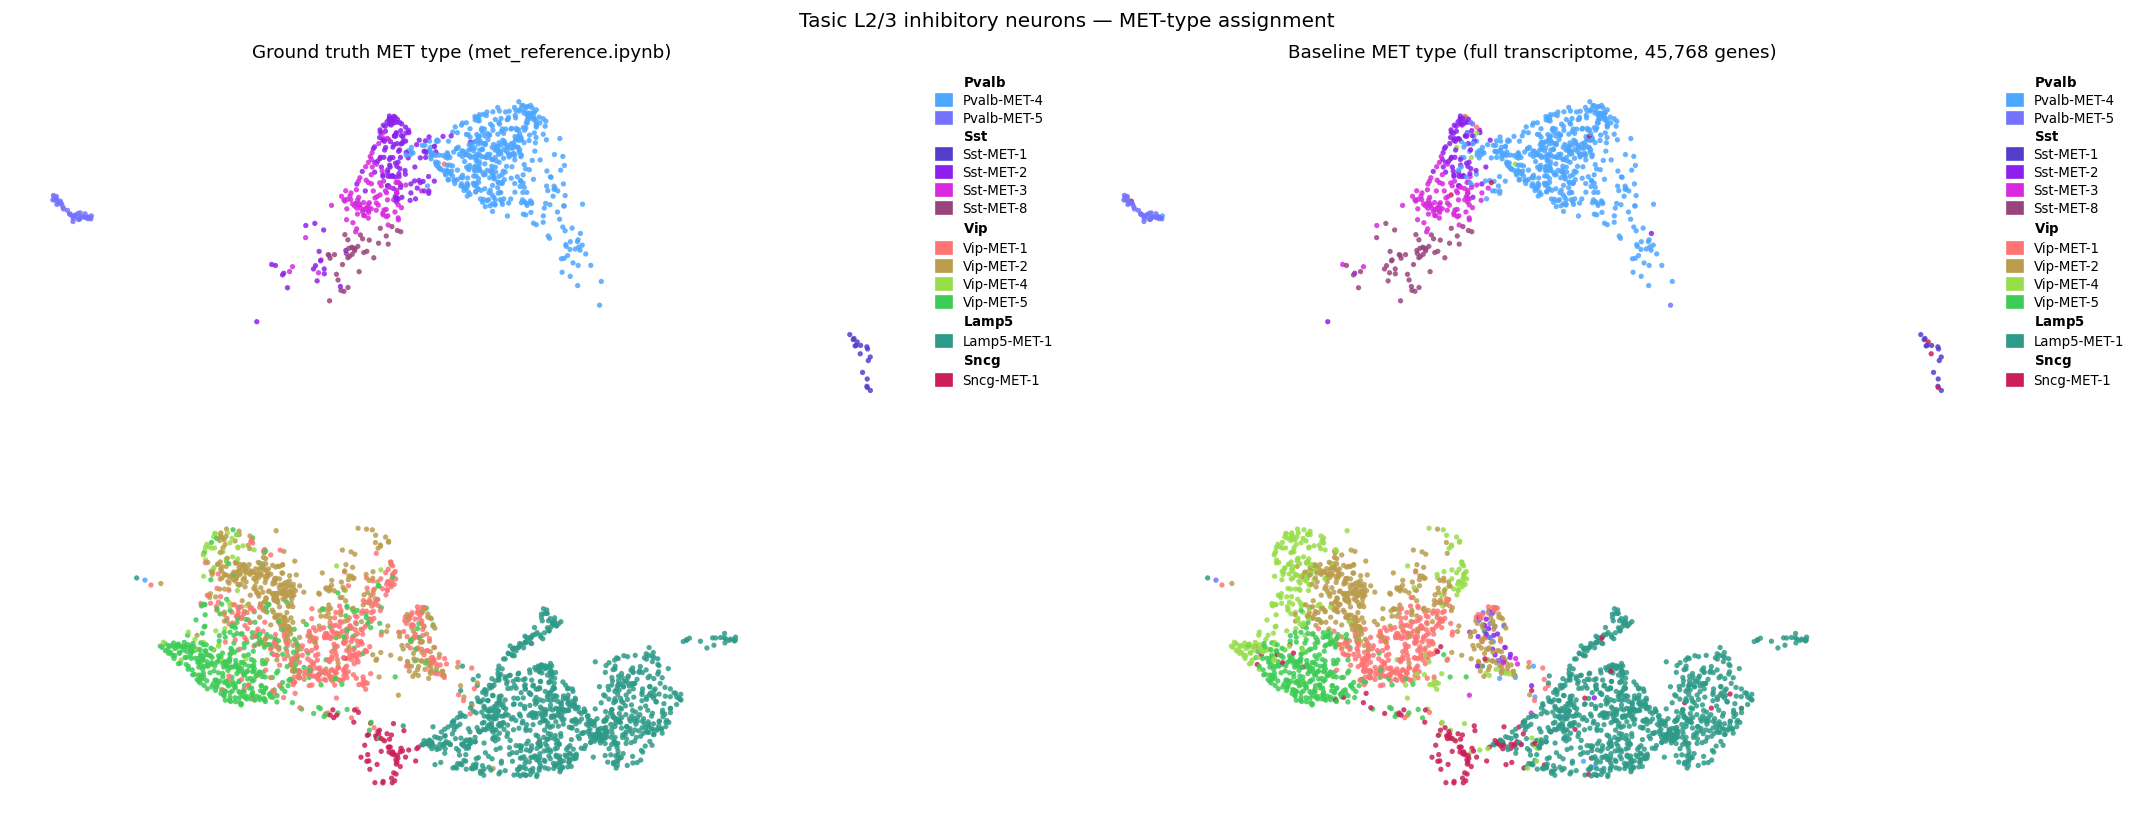

In [13]:
## UMAP: ground-truth MET type (left) | baseline prediction (right)

obs_full = adata_l23_inh.obs[['subclass', 'cluster']].copy()
obs_full = obs_full[obs_full['cluster'].isin(valid_clusters)]
cell_pos = adata_l23_inh.obs_names.get_indexer(obs_full.index)
umap     = adata_l23_inh.obsm['X_umap'][cell_pos]

colors_left  = np.array([
    met_color.get(gt_aligned[i], np.array([0.5, 0.5, 0.5]))
    for i in cell_pos
])
colors_right = np.array([
    met_color.get(pred_met_baseline[i], np.array([0.5, 0.5, 0.5]))
    for i in cell_pos
])

rng = np.random.default_rng(42)
idx = rng.permutation(len(umap))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
scatter_kw = dict(s=10, linewidths=0, alpha=0.85, rasterized=True)

axes[0].scatter(umap[idx, 0], umap[idx, 1], c=colors_left[idx],  **scatter_kw)
axes[1].scatter(umap[idx, 0], umap[idx, 1], c=colors_right[idx], **scatter_kw)

for ax, title in zip(axes, [
    'Ground truth MET type (met_reference.ipynb)',
    f'Baseline MET type (full transcriptome, {len(shared_genes):,} genes)',
]):
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

# MET-type legend (both panels share the same scheme)
handles_met = []
for sc in SUBCLASS_ORDER:
    mets = subclass_to_mets[sc]
    if not mets:
        continue
    handles_met.append(mpatches.Patch(facecolor='none', edgecolor='none', label=f'$\\bf{{{sc}}}$'))
    for m in mets:
        handles_met.append(mpatches.Patch(color=met_color[m], label=m))

for ax in axes:
    ax.legend(handles=handles_met, bbox_to_anchor=(1.02, 1), loc='upper left',
              fontsize=8, frameon=False, handlelength=1.2, handleheight=1.0,
              borderpad=0, labelspacing=0.3)

plt.suptitle('Tasic L2/3 inhibitory neurons — MET-type assignment', fontsize=12)
plt.tight_layout()
plt.show()

Selected 229 Sst cells assigned to focus MET types:
Sst-MET-3      110
Sst-MET-2       77
Pvalb-MET-4     42


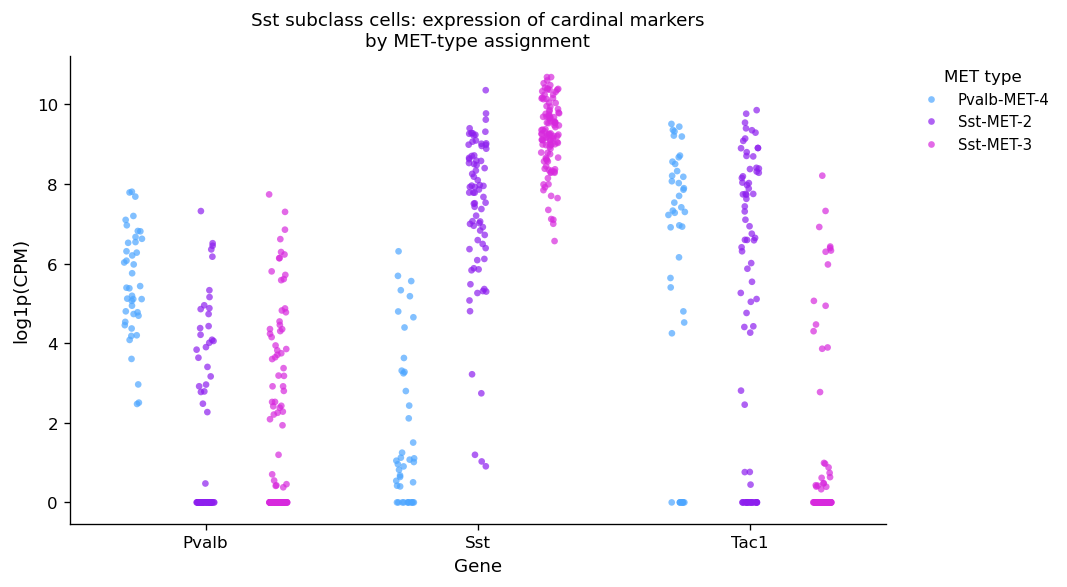

In [15]:
## Stripplot: Pvalb/Sst/Tac1 expression in Sst cells split by MET-type assignment

FOCUS_METS  = ['Pvalb-MET-4','Sst-MET-2', 'Sst-MET-3']
FOCUS_GENES = ['Pvalb', 'Sst', 'Tac1']

sst_mask  = true_subclass == 'Sst'
met_mask  = np.isin(pred_met_baseline, FOCUS_METS)
sel_mask  = sst_mask & met_mask
sel_idx   = np.where(sel_mask)[0]

print(f'Selected {sel_mask.sum()} Sst cells assigned to focus MET types:')
print(pd.Series(pred_met_baseline[sel_mask]).value_counts().to_string())

rows = []
for gene in FOCUS_GENES:
    if gene not in shared_gene_pos:
        print(f'WARNING: {gene} not in shared genes')
        continue
    expr = X_log[sel_idx, shared_gene_pos[gene]]
    for val, met in zip(expr, pred_met_baseline[sel_idx]):
        rows.append({'gene': gene, 'log1p_CPM': val, 'MET type': met})

df_sw = pd.DataFrame(rows)
palette = {m: tuple(met_color[m]) for m in FOCUS_METS}

fig, ax = plt.subplots(figsize=(9, 5))
sns.stripplot(
    data=df_sw, x='gene', y='log1p_CPM', hue='MET type',
    hue_order=FOCUS_METS, palette=palette,
    dodge=True, size=4, jitter=True, alpha=0.7, ax=ax,
)
ax.set_xlabel('Gene', fontsize=11)
ax.set_ylabel('log1p(CPM)', fontsize=11)
ax.set_title('Sst subclass cells: expression of cardinal markers\nby MET-type assignment', fontsize=11)
ax.legend(title='MET type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### To what degree do we need the Sncg gene for Sncg subclass assignment?

Cell counts per subclass:
Vip      1327
Lamp5     981
Sncg       66


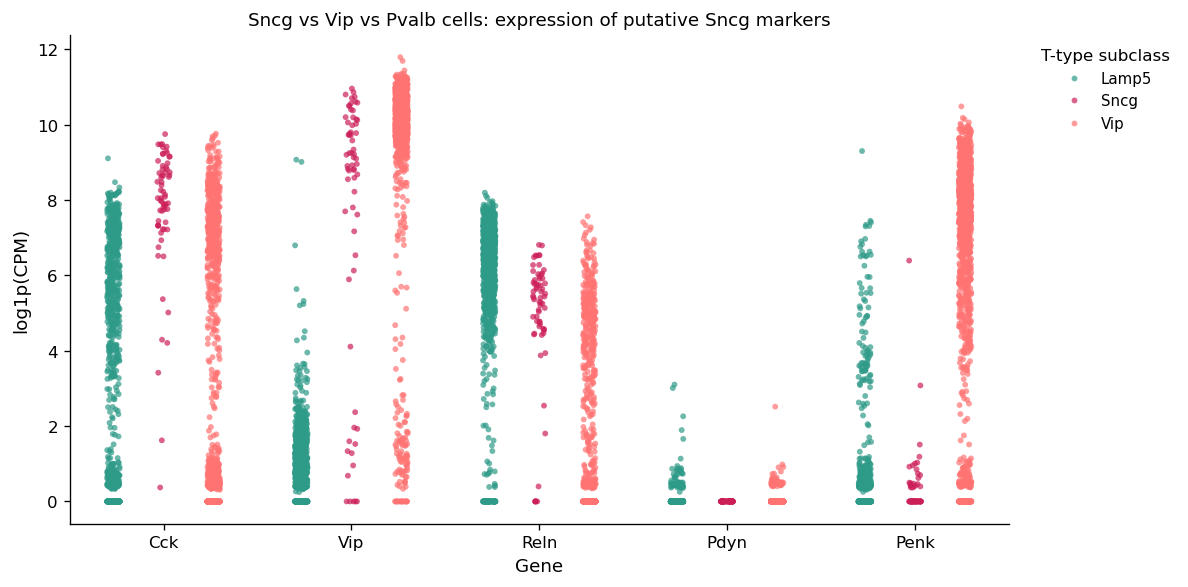

In [94]:
## Stripplot: Cck/Vip/Reln/Pvalb expression by T-type subclass (Sncg vs Vip vs Pvalb)

SNCG_GENES    = ['Cck', 'Vip', 'Reln','Pdyn','Penk']
SNCG_SUBCLASS = ['Lamp5','Sncg', 'Vip']

subclass_mask = np.isin(true_subclass, SNCG_SUBCLASS)
sel_idx       = np.where(subclass_mask)[0]

print('Cell counts per subclass:')
print(pd.Series(true_subclass[sel_idx]).value_counts().to_string())

rows = []
for gene in SNCG_GENES:
    if gene not in shared_gene_pos:
        print(f'WARNING: {gene} not in shared genes')
        continue
    expr = X_log[sel_idx, shared_gene_pos[gene]]
    for val, sc in zip(expr, true_subclass[sel_idx]):
        rows.append({'gene': gene, 'log1p_CPM': val, 'subclass': sc})

df_sw2 = pd.DataFrame(rows)
sc_palette = {sc: tuple(met_color[subclass_to_mets[sc][0]]) for sc in SNCG_SUBCLASS}

fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(
    data=df_sw2, x='gene', y='log1p_CPM', hue='subclass',
    hue_order=SNCG_SUBCLASS, palette=sc_palette,
    dodge=True, size=3.5, jitter=True, alpha=0.7, ax=ax,
)
ax.set_xlabel('Gene', fontsize=11)
ax.set_ylabel('log1p(CPM)', fontsize=11)
ax.set_title('Sncg vs Vip vs Pvalb cells: expression of putative Sncg markers', fontsize=11)
ax.legend(title='T-type subclass', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=9, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

In [81]:
## Exhaustive binarized conjunctive (AND) rule search: which gene combos identify Sncg?
# Tests all k=1,2,3 gene subsets with all polarity assignments (gene+ or gene-)
# Scores each rule by precision / recall / F1 for Sncg vs {Lamp5, Vip, Pvalb}.

from itertools import combinations, product
from sklearn.metrics import f1_score, precision_score, recall_score

# SNCG_GENES          = ['Sst', 'Pvalb', 'Vip', 'Lamp5','Gad2', 'Cck', 'Chat', 'Tac1', 'Crh', 'Penk',
#             'Pdyn', 'Calb2', 'Reln', 'Tac2', 'Calb1', 'Mme', 'Ndnf', 'Hpse', 'Pthlh', 'Npy']
SNCG_GENES = ['Sncg','Vip' , 'Cck' , 'Penk' , 'Calb2' , 'Pdyn' , 'Chat' , 'Reln' , 'Pthlh']
SNCG_GENES_ALREADY_HAVE = ['Sst', 'Pvalb', 'Vip', 'Lamp5','Chat', 'Tac1', 'Crh', 'Gad2', 'Penk', 'Pdyn',
                'Calb2', 'Cck']
SNCG_SUBCLASS       = ['Lamp5', 'Sncg', 'Vip']

# ── Fit GMMs for any genes not already in gmm_thresholds ────────────────────
all_thresholds = dict(gmm_thresholds)
for gene in SNCG_GENES:
    if gene in all_thresholds or gene not in shared_gene_pos:
        continue
    log_expr = X_log[:, shared_gene_pos[gene]]
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(log_expr.reshape(-1, 1))
    order  = np.argsort(gmm.means_.ravel())
    hi_idx = int(order[1])
    def _find_t(prob, _gmm=gmm, _hi=hi_idx, _max=float(log_expr.max())):
        def score(x): return _gmm.predict_proba([[x]])[0][_hi] - prob
        try: return brentq(score, 0.0, _max + 2.0)
        except ValueError: return np.nan
    all_thresholds[gene] = _find_t(THRESHOLD_PROB)
    t = all_thresholds[gene]
    pct = (X_log[:, shared_gene_pos[gene]] > t).mean() * 100
    print(f'  GMM fitted {gene}: threshold={t:.2f}  {pct:.1f}% positive')

# ── Binarize cells in the four subclasses ───────────────────────────────────
sc_mask = np.isin(true_subclass, SNCG_SUBCLASS)
sc_idx  = np.where(sc_mask)[0]
y_true  = (true_subclass[sc_idx] == 'Sncg').astype(int)
print(f'\nCells selected: {len(sc_idx)}  (Sncg: {y_true.sum()}, non-Sncg: {(1-y_true).sum()})')

present_genes = [g for g in SNCG_GENES if g in shared_gene_pos]
binary_mat = np.zeros((len(sc_idx), len(present_genes)), dtype=np.uint8)
for j, gene in enumerate(present_genes):
    t = all_thresholds.get(gene, np.nan)
    if not np.isnan(t):
        binary_mat[:, j] = (X_log[sc_idx, shared_gene_pos[gene]] > t).astype(np.uint8)

# ── Exhaustive conjunctive (AND) rule search ─────────────────────────────────
already_have_set = set(SNCG_GENES_ALREADY_HAVE)
results = []
for k in range(1, 9):
    for gene_idx_combo in combinations(range(len(present_genes)), k):
        gene_names = [present_genes[i] for i in gene_idx_combo]
        for polarities in product((1, 0), repeat=k):
            match = np.ones(len(sc_idx), dtype=bool)
            for col, pol in zip(gene_idx_combo, polarities):
                match &= binary_mat[:, col] == pol
            pred = match.astype(int)
            if pred.sum() == 0:
                continue
            terms = [f'{g}{chr(8314) if p else chr(8315)}' for g, p in zip(gene_names, polarities)]
            results.append({
                'k':              k,
                'rule':           ' & '.join(terms),
                'uses_Sncg':      'Sncg' in gene_names,
                'needs_new_probe': not all(g in already_have_set for g in gene_names),
                'precision':      precision_score(y_true, pred, zero_division=0),
                'recall':         recall_score(y_true, pred, zero_division=0),
                'F1':             f1_score(y_true, pred, zero_division=0),
                'n_pos':          int(pred.sum()),
            })

df_rules = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print(f'Rules tested: {len(df_rules)}')

cols = ['rule', 'k', 'uses_Sncg', 'needs_new_probe', 'precision', 'recall', 'F1', 'n_pos']

print('\n── Top 15 rules (all genes) ──────────────────────────────────────────────')
print(df_rules[cols].head(15).to_string(index=False))

print('\n── Top 15 rules WITHOUT Sncg probe ──────────────────────────────────────')
df_no_sncg = df_rules[~df_rules['uses_Sncg']].reset_index(drop=True)
print(df_no_sncg[cols].head(15).to_string(index=False))

print('\n── Top 15 rules using only probes already in hand ────────────────────────')
df_in_hand = df_rules[~df_rules['uses_Sncg'] & ~df_rules['needs_new_probe']].reset_index(drop=True)
print(df_in_hand[cols].head(15).to_string(index=False))


  GMM fitted Cck: threshold=1.39  49.1% positive
  GMM fitted Penk: threshold=1.13  38.2% positive
  GMM fitted Calb2: threshold=0.01  42.9% positive
  GMM fitted Pdyn: threshold=0.01  9.9% positive
  GMM fitted Chat: threshold=0.01  10.1% positive
  GMM fitted Reln: threshold=0.01  51.7% positive
  GMM fitted Pthlh: threshold=0.01  55.0% positive

Cells selected: 2374  (Sncg: 66, non-Sncg: 2308)
Rules tested: 13125

── Top 15 rules (all genes) ──────────────────────────────────────────────
                                                rule  k  uses_Sncg  needs_new_probe  precision   recall       F1  n_pos
                               Sncg⁺ & Penk⁻ & Pdyn⁻  3       True             True   0.586207 0.772727 0.666667     87
                        Sncg⁺ & Cck⁺ & Penk⁻ & Pdyn⁻  4       True             True   0.595238 0.757576 0.666667     84
                       Sncg⁺ & Cck⁺ & Pdyn⁻ & Pthlh⁻  4       True             True   0.579545 0.772727 0.662338     88
                       S

In [133]:
df_rules.sort_values('F1')[-20:][::-1]

,k,rule,uses_Sncg,needs_new_probe,precision,recall,F1,n_pos
0,3,Sncg⁺ & Penk⁻ & Pdyn⁻,True,True,0.586207,0.772727,0.666667,87
1,4,Sncg⁺ & Cck⁺ & Penk⁻ & Pdyn⁻,True,True,0.595238,0.757576,0.666667,84
2,4,Sncg⁺ & Cck⁺ & Pdyn⁻ & Pthlh⁻,True,True,0.579545,0.772727,0.662338,88
3,4,Sncg⁺ & Penk⁻ & Pdyn⁻ & Chat⁻,True,True,0.581395,0.757576,0.657895,86
4,5,Sncg⁺ & Cck⁺ & Penk⁻ & Pdyn⁻ & Chat⁻,True,True,0.590361,0.742424,0.657718,83
5,3,Sncg⁺ & Cck⁺ & Pdyn⁻,True,True,0.545455,0.818182,0.654545,99
6,2,Sncg⁺ & Penk⁻,True,True,0.566667,0.772727,0.653846,90
7,5,Sncg⁺ & Cck⁺ & Pdyn⁻ & Chat⁻ & Pthlh⁻,True,True,0.574713,0.757576,0.653595,87
8,3,Sncg⁺ & Cck⁺ & Penk⁻,True,True,0.574713,0.757576,0.653595,87
9,4,Sncg⁺ & Penk⁻ & Pdyn⁻ & Pthlh⁻,True,True,0.592593,0.727273,0.653061,81


Baseline:          full transcriptome two-step
Best in-hand rule: Vip⁺ & Penk⁻  (F1=0.243)
Best new-probe:    Sncg⁺ & Penk⁻  (F1=0.654)


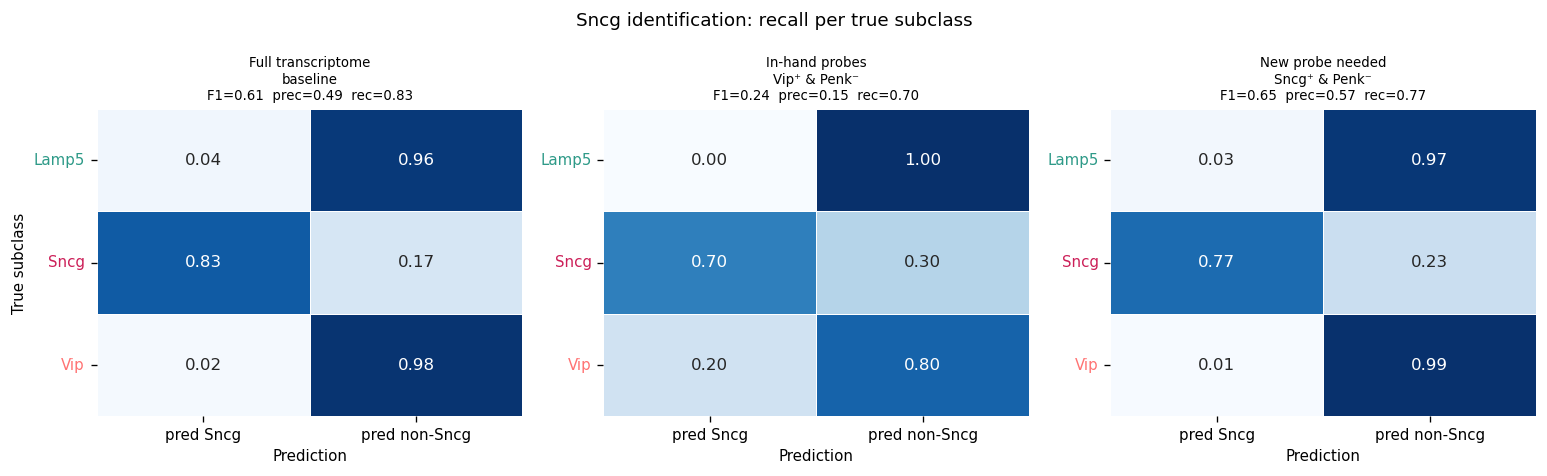

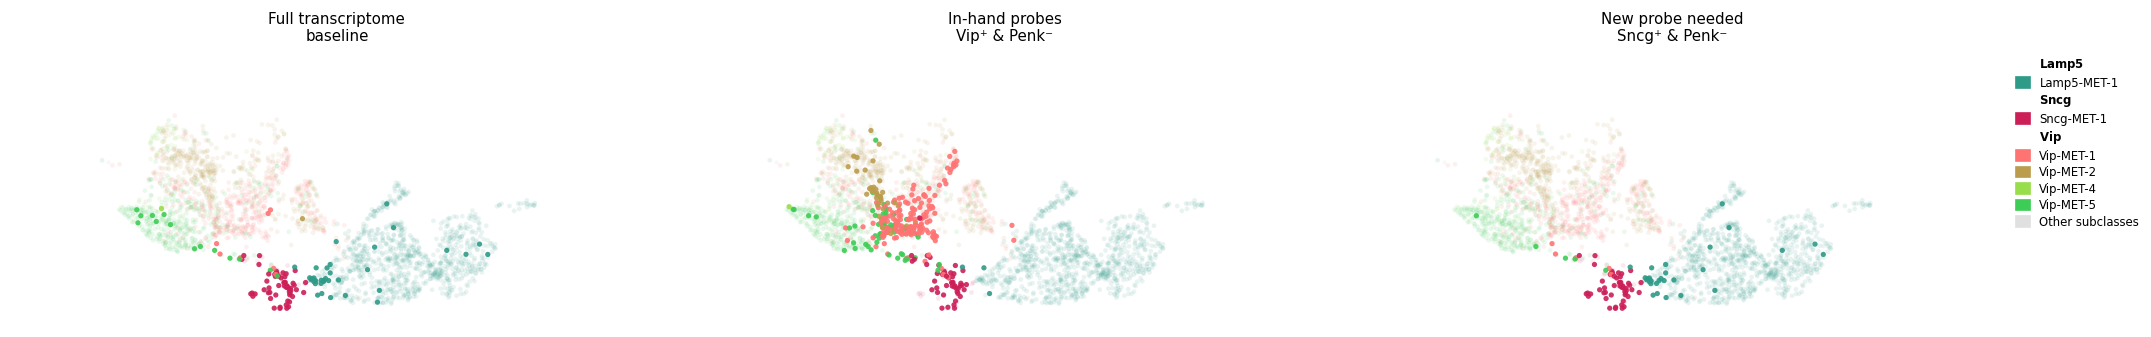

In [156]:
## 3-way Sncg classification comparison: confusion matrices + UMAPs

# ── Identify best rules from df_rules ────────────────────────────────────────
best_in_hand   = df_rules[~df_rules['needs_new_probe'] & (df_rules['k'] == 2)].sort_values('F1')[::-1].iloc[0]
best_new_probe = df_rules[df_rules['needs_new_probe'] & (df_rules['k'] == 2)].sort_values('F1')[::-1].iloc[0]
print(f'Baseline:          full transcriptome two-step')
print(f'Best in-hand rule: {best_in_hand["rule"]}  (F1={best_in_hand["F1"]:.3f})')
print(f'Best new-probe:    {best_new_probe["rule"]}  (F1={best_new_probe["F1"]:.3f})')

# ── Parse 'Gene⁺ & Gene⁻ & ...' rule string into binary predictions ──────────
def apply_rule(rule_str, bmat, genes):
    pred = np.ones(bmat.shape[0], dtype=bool)
    for term in rule_str.split('&'):
        term = term.strip()
        if chr(8314) in term:
            gene, pol = term.replace(chr(8314), '').strip(), 1
        else:
            gene, pol = term.replace(chr(8315), '').strip(), 0
        if gene in genes:
            pred &= bmat[:, genes.index(gene)] == pol
    return pred.astype(int)

pred_baseline  = pd.Series(pred_met_baseline[sc_idx]).str.startswith('Sncg').astype(int).values
pred_in_hand   = apply_rule(best_in_hand['rule'],   binary_mat, present_genes)
pred_new_probe = apply_rule(best_new_probe['rule'], binary_mat, present_genes)

true_subclass_sc = true_subclass[sc_idx]
conditions = [
    ('Full transcriptome\nbaseline',                pred_baseline),
    (f'In-hand probes\n{best_in_hand["rule"]}',     pred_in_hand),
    (f'New probe needed\n{best_new_probe["rule"]}', pred_new_probe),
]

# Subclass representative color: median met_color within each subclass
# (uses same varibow met_color dict as all other viz cells)
sc_label_color = {sc: tuple(met_color[subclass_to_mets[sc][0]]) for sc in SNCG_SUBCLASS}

# ── Figure 1: Confusion matrices (row-normalised recall) ──────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (title, pred) in zip(axes, conditions):
    f1   = f1_score(y_true, pred, zero_division=0)
    prec = precision_score(y_true, pred, zero_division=0)
    rec  = recall_score(y_true, pred, zero_division=0)

    conf = pd.DataFrame(0, index=SNCG_SUBCLASS, columns=['pred Sncg', 'pred non-Sncg'])
    for t, p in zip(true_subclass_sc, pred):
        if t in SNCG_SUBCLASS:
            conf.loc[t, 'pred Sncg' if p == 1 else 'pred non-Sncg'] += 1
    conf_norm = conf.div(conf.sum(axis=1).replace(0, 1), axis=0)

    sns.heatmap(
        conf_norm, ax=ax, cmap='Blues', vmin=0, vmax=1,
        annot=True, fmt='.2f', annot_kws={'size': 10},
        linewidths=0.5, cbar=False,
    )
    for tick in ax.get_yticklabels():
        tick.set_color(sc_label_color[tick.get_text()])
        tick.set_fontsize(9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_ylabel('True subclass' if ax == axes[0] else '', fontsize=9)
    ax.set_xlabel('Prediction', fontsize=9)
    ax.set_title(f'{title}\nF1={f1:.2f}  prec={prec:.2f}  rec={rec:.2f}', fontsize=8)

plt.suptitle('Sncg identification: recall per true subclass', fontsize=11)
plt.tight_layout()
plt.show()

# ── Figure 2: UMAPs colored by varibow MET type ───────────────────────────────
# Each cell is colored by its ground-truth MET type (met_color, same as all
# other UMAP cells). Alpha encodes prediction: predicted-Sncg cells are bright,
# non-predicted SNCG_SUBCLASS cells are faded. False positives therefore appear
# as bright dots in the wrong subclass hue.

umap_all = adata_l23_inh.obsm['X_umap']
bg_col   = np.array([0.88, 0.88, 0.88])
rng      = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
scatter_kw = dict(linewidths=0, rasterized=True)

for ax, (title, pred) in zip(axes, conditions):
    # 1. Grey background: cells outside SNCG_SUBCLASS
    bg_idx = rng.permutation(np.where(~np.isin(true_subclass, SNCG_SUBCLASS))[0])
    ax.scatter(umap_all[bg_idx, 0], umap_all[bg_idx, 1],
               c=[bg_col], alpha=0.2, s=6, **scatter_kw)

    # 2. Not-predicted SNCG_SUBCLASS cells: varibow MET color, faded
    not_pred_idx = sc_idx[pred == 0]
    not_pred_colors = np.array([
        met_color.get(gt_aligned[i], bg_col) for i in not_pred_idx
    ])
    ax.scatter(umap_all[not_pred_idx, 0], umap_all[not_pred_idx, 1],
               c=not_pred_colors, alpha=0.1, s=8, **scatter_kw)

    # 3. Predicted-Sncg cells: varibow MET color, full brightness
    #    (true Sncg cells → Sncg hue; false positives → their own subclass hue)
    pred_idx    = sc_idx[pred == 1]
    pred_colors = np.array([
        met_color.get(gt_aligned[i], bg_col) for i in pred_idx
    ])
    ax.scatter(umap_all[pred_idx, 0], umap_all[pred_idx, 1],
               c=pred_colors, alpha=0.9, s=10, **scatter_kw)

    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')
    ax.set_ylim([-8,5])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Legend: per-MET-type varibow colors for SNCG_SUBCLASS
handles = []
for sc in SNCG_SUBCLASS:
    handles.append(mpatches.Patch(facecolor='none', edgecolor='none', label=f'$\\bf{{{sc}}}$'))
    for m in subclass_to_mets[sc]:
        handles.append(mpatches.Patch(color=met_color[m], label=m))
handles.append(mpatches.Patch(color=bg_col, label='Other subclasses'))
axes[-1].legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left',
                fontsize=7, frameon=False, handlelength=1.2, handleheight=1.0,
                borderpad=0, labelspacing=0.3)

# plt.suptitle(
#     'UMAP: bright = predicted Sncg, faded = not predicted',
#     fontsize=11,
# )
plt.tight_layout()
plt.show()


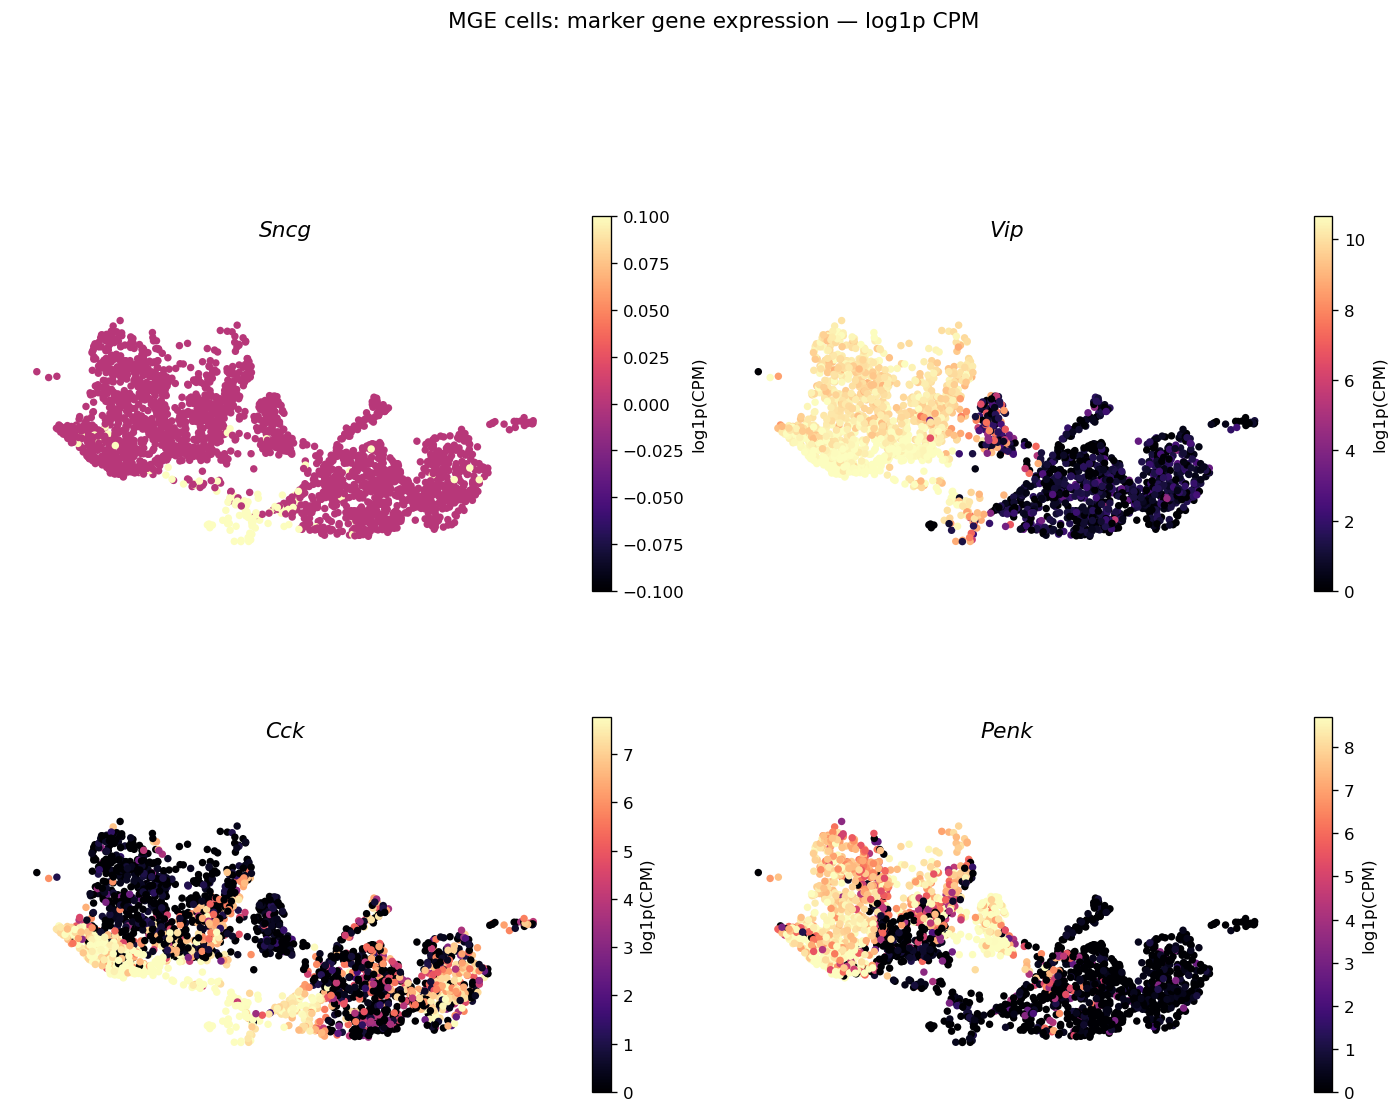

In [157]:
## Lamp5 subtype marker expression on UMAP

LAMP5_MARKERS = ['Sncg', 'Vip', 'Cck', 'Penk']

mge_mask = np.isin(adata_l23_inh.obs['subclass'], ['Sncg','Lamp5','Vip'])
umap_lamp5 = adata_l23_inh.obsm['X_umap'][mge_mask]

gene_expr = {}
for g in LAMP5_MARKERS:
    entrez = sym_to_entrez.get(g)
    if entrez is None:
        print(f'Warning: {g} not found in Tasic gene set')
        continue
    col = adata_l23_inh.var_names.get_loc(entrez)
    raw = adata_l23_inh.layers['counts'][mge_mask, col]
    if hasattr(raw, 'toarray'):
        raw = raw.toarray().ravel()
    else:
        raw = np.asarray(raw).ravel()
    gene_expr[g] = np.log1p(raw / cell_total[mge_mask].squeeze() * 1e6)

rng = np.random.default_rng(42)
idx = rng.permutation(mge_mask.sum())

n_cols = 2
n_rows = int(np.ceil(len(gene_expr) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

for ax, g in zip(np.array(axes).ravel(), gene_expr):
    expr = gene_expr[g][idx]
    vmax = np.quantile(expr,.9) # all_thresholds[g]# *1.1
    sc = ax.scatter(
        umap_lamp5[idx, 0], umap_lamp5[idx, 1],
        c=expr, cmap='magma', s=20, linewidths=0,
        vmin=0, vmax=vmax, rasterized=True,
    )
    ax.set_title(g, fontsize=13, style='italic')
    ax.set_aspect('equal')
    ax.set_ylim([-8,5])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.colorbar(sc, ax=ax, shrink=0.6, label='log1p(CPM)')

# Hide any unused axes
for ax in np.array(axes).ravel()[len(gene_expr):]:
    ax.set_visible(False)

fig.suptitle('MGE cells: marker gene expression — log1p CPM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Lamp5 continuous differentiation

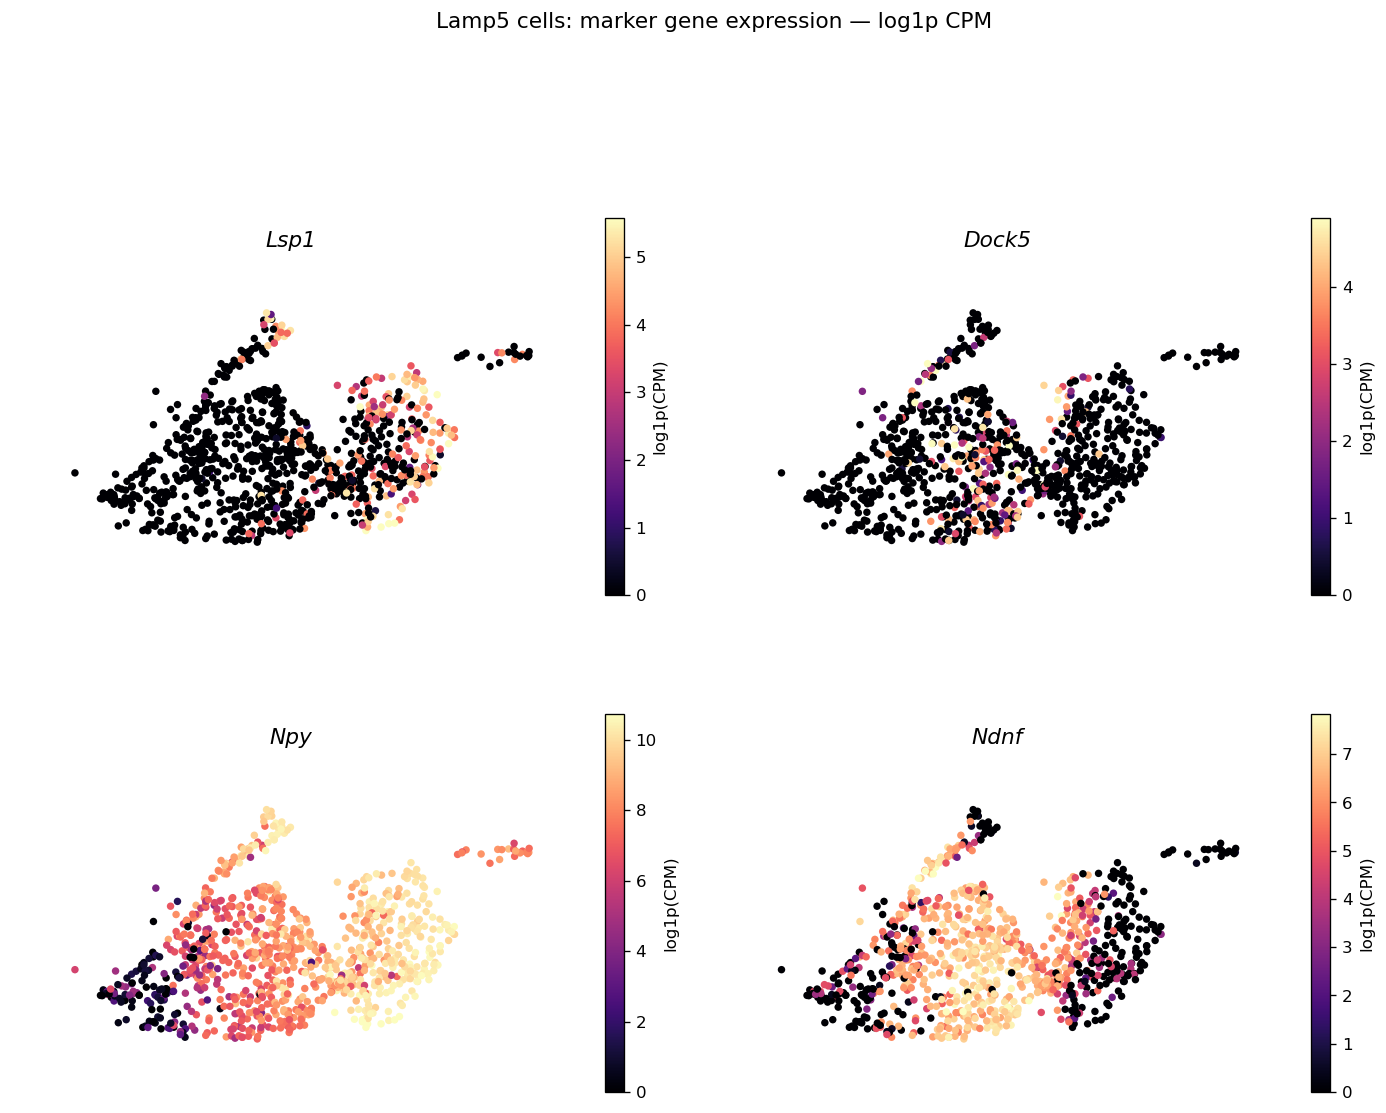

In [158]:
## Lamp5 subtype marker expression on UMAP

LAMP5_MARKERS = ['Lsp1', 'Dock5', 'Npy', 'Ndnf']

## Lamp5 subtype marker expression on UMAP

lamp5_mask = (adata_l23_inh.obs['subclass'] == 'Lamp5').values
umap_lamp5 = adata_l23_inh.obsm['X_umap'][lamp5_mask]

gene_expr = {}
for g in LAMP5_MARKERS:
    entrez = sym_to_entrez.get(g)
    if entrez is None:
        print(f'Warning: {g} not found in Tasic gene set')
        continue
    col = adata_l23_inh.var_names.get_loc(entrez)
    raw = adata_l23_inh.layers['counts'][lamp5_mask, col]
    if hasattr(raw, 'toarray'):
        raw = raw.toarray().ravel()
    else:
        raw = np.asarray(raw).ravel()
    gene_expr[g] = np.log1p(raw / cell_total[lamp5_mask].squeeze() * 1e6)

rng = np.random.default_rng(42)
idx = rng.permutation(lamp5_mask.sum())

n_cols = 2
n_rows = int(np.ceil(len(gene_expr) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

for ax, g in zip(np.array(axes).ravel(), gene_expr):
    expr = gene_expr[g][idx]
    vmax = float(np.percentile(expr, 99)) or 1.0
    sc = ax.scatter(
        umap_lamp5[idx, 0], umap_lamp5[idx, 1],
        c=expr, cmap='magma', s=20, linewidths=0,
        vmin=0, vmax=vmax, rasterized=True,
    )
    ax.set_title(g, fontsize=13, style='italic')
    ax.set_aspect('equal')
    ax.set_xlim([-2,12])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.colorbar(sc, ax=ax, shrink=0.6, label='log1p(CPM)')

# Hide any unused axes
for ax in np.array(axes).ravel()[len(gene_expr):]:
    ax.set_visible(False)

fig.suptitle('Lamp5 cells: marker gene expression — log1p CPM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Pvalb chandelier cell IDing

Pvalb-MET-4: 471 cells  |  Pvalb-MET-5: 42 cells
sig
ns             44204
Pvalb-MET-4     1097
Pvalb-MET-5      467


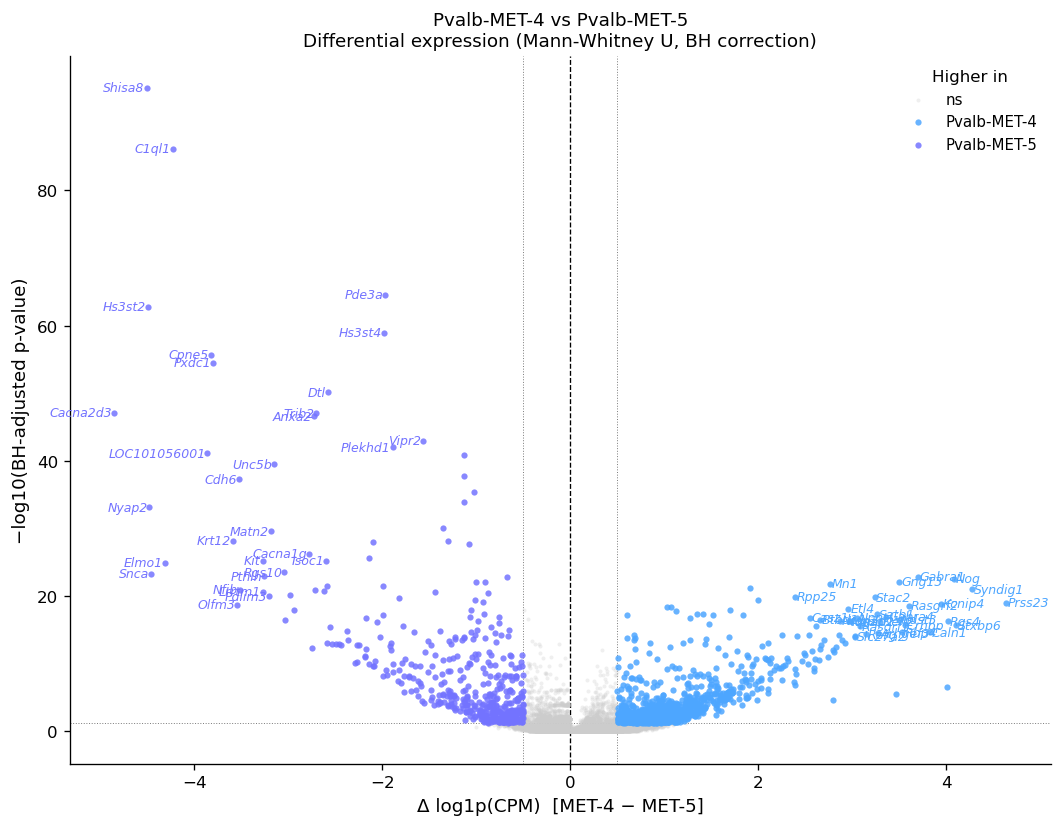

In [200]:
## Volcano plot: Pvalb-MET-4 vs Pvalb-MET-5 (chandelier vs non-chandelier)

from scipy import stats
from statsmodels.stats.multitest import multipletests

# ── Select cells by ground-truth MET assignment ───────────────────────────────
mask4 = gt_aligned == 'Pvalb-MET-4'
mask5 = gt_aligned == 'Pvalb-MET-5'
X4, X5 = X_log[mask4], X_log[mask5]
print(f'Pvalb-MET-4: {mask4.sum()} cells  |  Pvalb-MET-5: {mask5.sum()} cells')

# ── Differential expression: Mann-Whitney U + BH correction ──────────────────
mean4 = X4.mean(axis=0)
mean5 = X5.mean(axis=0)
lfc   = mean4 - mean5          # Δ log1p(CPM); positive = higher in MET-4

pvals = np.array([
    stats.mannwhitneyu(X4[:, j], X5[:, j], alternative='two-sided').pvalue
    for j in range(len(shared_genes))
])
_, padj, _, _ = multipletests(pvals, method='fdr_bh')

df_de = pd.DataFrame({
    'gene':       shared_genes,
    'lfc':        lfc,
    'padj':       padj,
    'neg_log10p': -np.log10(np.clip(padj, 1e-300, 1)),
})

SIG_PADJ, SIG_LFC = 0.05, 0.5
df_de['sig'] = 'ns'
df_de.loc[(df_de['padj'] < SIG_PADJ) & (df_de['lfc'] >  SIG_LFC), 'sig'] = 'Pvalb-MET-4'
df_de.loc[(df_de['padj'] < SIG_PADJ) & (df_de['lfc'] < -SIG_LFC), 'sig'] = 'Pvalb-MET-5'
print(df_de['sig'].value_counts().to_string())

# Top genes to label: ranked by -log10(padj) × |lfc|
df_de['score'] = df_de['neg_log10p'] * df_de['lfc'].abs()
N_LABEL = 30
to_label = pd.concat([
    df_de[df_de['sig'] == 'Pvalb-MET-4'].nlargest(N_LABEL, 'score'),
    df_de[df_de['sig'] == 'Pvalb-MET-5'].nlargest(N_LABEL, 'score'),
])

# ── Volcano plot ──────────────────────────────────────────────────────────────
col4 = tuple(met_color.get('Pvalb-MET-4', (0.8, 0.1, 0.1)))
col5 = tuple(met_color.get('Pvalb-MET-5', (0.2, 0.2, 0.8)))
palette = {'ns': '#cccccc', 'Pvalb-MET-4': col4, 'Pvalb-MET-5': col5}

fig, ax = plt.subplots(figsize=(9, 7))
for cat, color in palette.items():
    sub = df_de[df_de['sig'] == cat]
    ax.scatter(sub['lfc'], sub['neg_log10p'],
               c=[color], s=6 if cat == 'ns' else 14,
               alpha=0.3 if cat == 'ns' else 0.85,
               linewidths=0, label=cat, rasterized=True)

# Threshold lines
ax.axvline(0,         color='black', lw=0.8, ls='--', zorder=0)
ax.axvline( SIG_LFC,  color='grey',  lw=0.6, ls=':',  zorder=0)
ax.axvline(-SIG_LFC,  color='grey',  lw=0.6, ls=':',  zorder=0)
ax.axhline(-np.log10(SIG_PADJ), color='grey', lw=0.6, ls=':', zorder=0)

# Gene labels
for _, row in to_label.iterrows():
    ha = 'left' if row['lfc'] > 0 else 'right'
    dx = 0.02 if row['lfc'] > 0 else -0.02
    ax.text(row['lfc'] + dx, row['neg_log10p'], row['gene'],
            fontsize=7.5, ha=ha, va='center', style='italic',
            color=palette[row['sig']])

ax.set_xlabel('Δ log1p(CPM)  [MET-4 − MET-5]', fontsize=11)
ax.set_ylabel('−log10(BH-adjusted p-value)', fontsize=11)
ax.set_title('Pvalb-MET-4 vs Pvalb-MET-5\nDifferential expression (Mann-Whitney U, BH correction)',
             fontsize=11)
ax.legend(title='Higher in', fontsize=9, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


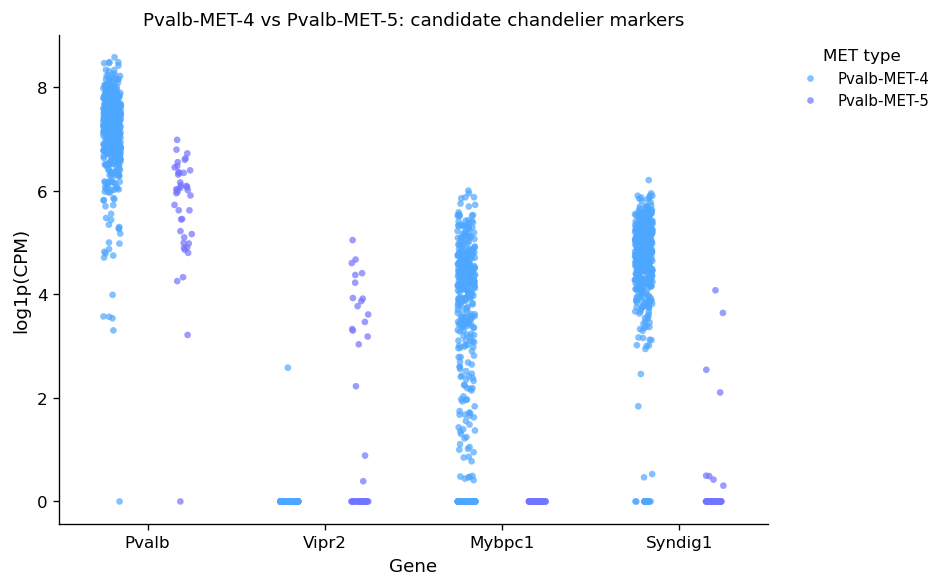

In [203]:
## Stripplot: Pvalb-MET-4 vs Pvalb-MET-5 candidate markers

PV_MARKERS = ['Pvalb','Vipr2', 'Mybpc1', 'Syndig1']
PV_METS    = ['Pvalb-MET-4', 'Pvalb-MET-5']

pv_mask   = np.isin(gt_aligned, PV_METS)
pv_idx    = np.where(pv_mask)[0]
pv_labels = gt_aligned[pv_idx]

rows = []
for gene in PV_MARKERS:
    if gene not in shared_gene_pos:
        print(f'WARNING: {gene} not in shared genes')
        continue
    expr = X_log[pv_idx, shared_gene_pos[gene]]
    for val, met in zip(expr, pv_labels):
        rows.append({'gene': gene, 'log1p_CPM': val, 'MET type': met})

df_pv = pd.DataFrame(rows)
palette = {m: tuple(met_color[m]) for m in PV_METS}

fig, ax = plt.subplots(figsize=(8, 5))
sns.stripplot(
    data=df_pv, x='gene', y='log1p_CPM', hue='MET type',
    hue_order=PV_METS, palette=palette,
    dodge=True, size=4, jitter=True, alpha=0.7, ax=ax,
)
ax.set_xlabel('Gene', fontsize=11)
ax.set_ylabel('log1p(CPM)', fontsize=11)
ax.set_title('Pvalb-MET-4 vs Pvalb-MET-5: candidate chandelier markers', fontsize=11)
ax.legend(title='MET type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


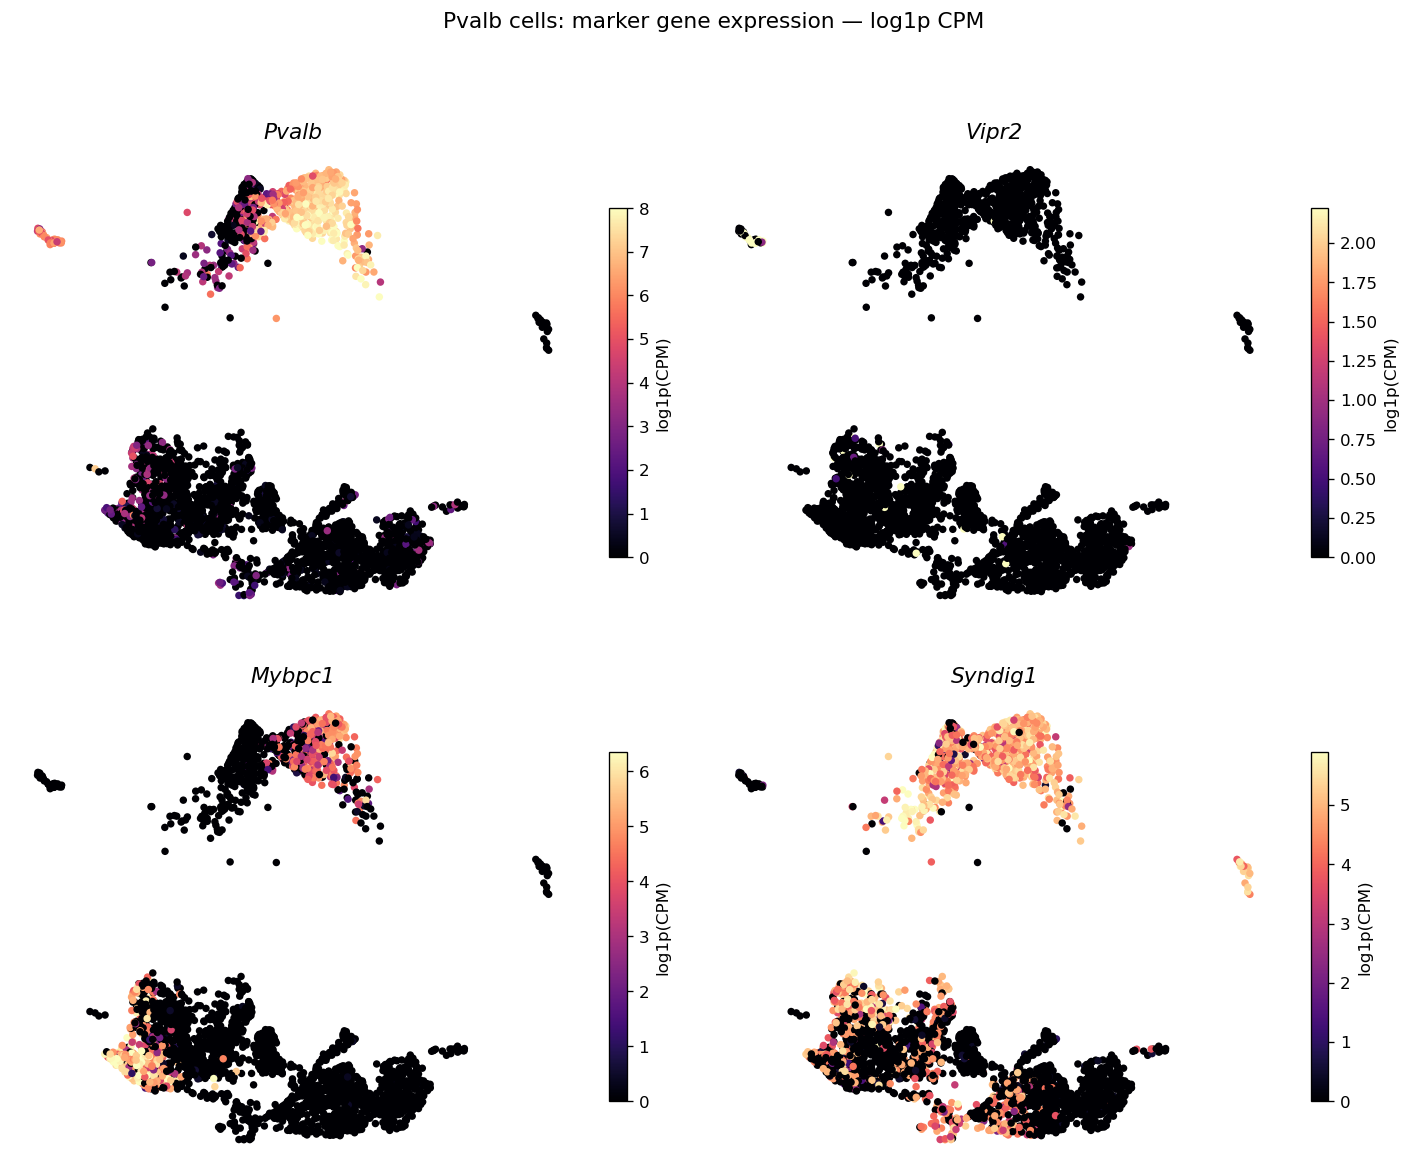

In [209]:
## SST subtype marker expression on UMAP

LAMP5_MARKERS = ['Pvalb','Vipr2','Mybpc1','Syndig1']

## SST subtype marker expression on UMAP

lamp5_mask = np.isin(adata_l23_inh.obs['subclass'],['Pvalb','Lamp5','Sncg','Sst','Vip'])  # (adata_l23_inh.obs['subclass'] == 'Pvalb').values
umap_lamp5 = adata_l23_inh.obsm['X_umap'][lamp5_mask]

gene_expr = {}
for g in LAMP5_MARKERS:
    entrez = sym_to_entrez.get(g)
    if entrez is None:
        print(f'Warning: {g} not found in Tasic gene set')
        continue
    col = adata_l23_inh.var_names.get_loc(entrez)
    raw = adata_l23_inh.layers['counts'][lamp5_mask, col]
    if hasattr(raw, 'toarray'):
        raw = raw.toarray().ravel()
    else:
        raw = np.asarray(raw).ravel()
    gene_expr[g] = np.log1p(raw / cell_total[lamp5_mask].squeeze() * 1e6)

rng = np.random.default_rng(42)
idx = rng.permutation(lamp5_mask.sum())

n_cols = 2
n_rows = int(np.ceil(len(gene_expr) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

for ax, g in zip(np.array(axes).ravel(), gene_expr):
    expr = gene_expr[g][idx]
    vmax = float(np.percentile(expr, 99)) or 1.0
    sc = ax.scatter(
        umap_lamp5[idx, 0], umap_lamp5[idx, 1],
        c=expr, cmap='magma', s=20, linewidths=0,
        vmin=0, vmax=vmax, rasterized=True,
    )
    ax.set_title(g, fontsize=13, style='italic')
    ax.set_aspect('equal')
    # ax.set_ylim([7.5,20])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.colorbar(sc, ax=ax, shrink=0.6, label='log1p(CPM)')

# Hide any unused axes
for ax in np.array(axes).ravel()[len(gene_expr):]:
    ax.set_visible(False)

fig.suptitle('Pvalb cells: marker gene expression — log1p CPM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Syndig1 GMM threshold: 0.006


/tmp/ipykernel_712638/99935979.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


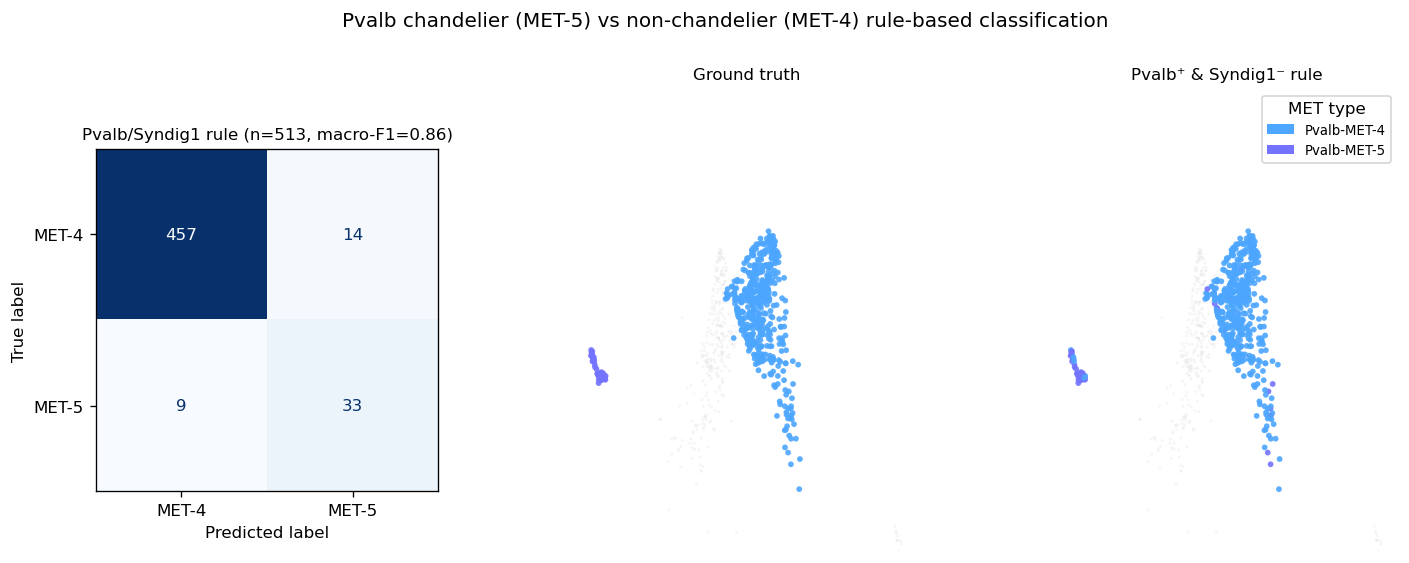

Macro F1: 0.859  |  n=513 cells


In [208]:
## Pvalb-MET-4 vs MET-5: binarized Pvalb+/Syndig1 rule + confusion matrix + UMAP
# Rule: among Pvalb-subclass cells (cardinal Pvalb)
#   Pvalb+ & Syndig1-  → Pvalb-MET-5  (putative chandelier)
#   Pvalb+ & Syndig1+  → Pvalb-MET-4  (putative non-chandelier)

PV_RULE_METS = ["Pvalb-MET-4", "Pvalb-MET-5"]

# --- binarize Pvalb and Syndig1 ---
pvalb_thresh  = all_thresholds["Pvalb"]
syndig1_thresh = all_thresholds.get("Syndig1", None)

# If Syndig1 not in all_thresholds, fit a quick GMM
syndig1_idx = shared_gene_pos.get("Syndig1")
if syndig1_thresh is None and syndig1_idx is not None:
    from sklearn.mixture import GaussianMixture
    vals = X_log[:, syndig1_idx].reshape(-1, 1)
    gm2 = GaussianMixture(n_components=2, random_state=0).fit(vals)
    mus = gm2.means_.flatten()
    sds = np.sqrt(gm2.covariances_.flatten())
    lo, hi = np.argsort(mus)
    from scipy.optimize import brentq
    syndig1_thresh = brentq(
        lambda x: gm2.predict_proba([[x]])[0, hi] - 0.95,
        mus[lo], mus[hi] + 3 * sds[hi]
    )
    print(f"Syndig1 GMM threshold: {syndig1_thresh:.3f}")
elif syndig1_thresh is not None:
    print(f"Syndig1 threshold from all_thresholds: {syndig1_thresh:.3f}")
else:
    raise ValueError("Syndig1 not found in shared gene space")

# Only evaluate on cells that ground-truth is Pvalb-MET-4 or Pvalb-MET-5
pv_rule_mask = np.isin(gt_aligned, PV_RULE_METS)
pv_rule_idx  = np.where(pv_rule_mask)[0]
gt_pv        = gt_aligned[pv_rule_mask]

pvalb_bin   = X_log[pv_rule_mask, shared_gene_pos["Pvalb"]] >= pvalb_thresh
syndig1_bin = X_log[pv_rule_mask, syndig1_idx]               <  syndig1_thresh  # negative

pred_pv = np.where(pvalb_bin & syndig1_bin, "Pvalb-MET-5", "Pvalb-MET-4")

# --- metrics ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.gridspec as gridspec

cm = confusion_matrix(gt_pv, pred_pv, labels=PV_RULE_METS)
f1 = f1_score(gt_pv, pred_pv, labels=PV_RULE_METS, average="macro")

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

ax_cm      = fig.add_subplot(gs[0])
ax_umap_gt = fig.add_subplot(gs[1])
ax_umap_pr = fig.add_subplot(gs[2])

disp = ConfusionMatrixDisplay(cm, display_labels=[m.replace("Pvalb-","") for m in PV_RULE_METS])
disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
ax_cm.set_title(f"Pvalb/Syndig1 rule (n={pv_rule_mask.sum()}, macro-F1={f1:.2f})", fontsize=10)

# --- UMAP panels ---
umap_xy = adata_l23_inh.obsm["X_umap"]
bg_col  = (0.88, 0.88, 0.88)

def _umap_panel(ax, colors_focus, idx_focus, title):
    ax.scatter(umap_xy[:, 0], umap_xy[:, 1],
               c=[bg_col]*len(umap_xy), s=3, alpha=0.3, linewidths=0, rasterized=True)
    ax.scatter(umap_xy[idx_focus, 0], umap_xy[idx_focus, 1],
               c=colors_focus, s=12, alpha=0.9, linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=10)
    ax.set_ylim([7.5,20])    
    ax.axis("off")

gt_colors   = [met_color.get(m, bg_col) for m in gt_pv]
pred_colors = [met_color.get(m, bg_col) for m in pred_pv]

_umap_panel(ax_umap_gt, gt_colors,   pv_rule_idx, "Ground truth")
_umap_panel(ax_umap_pr, pred_colors, pv_rule_idx, "Pvalb⁺ & Syndig1⁻ rule")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=met_color[m], label=m) for m in PV_RULE_METS]
ax_umap_pr.legend(handles=legend_elements, fontsize=8, loc="upper right",
                  framealpha=0.8, title="MET type")

fig.suptitle("Pvalb chandelier (MET-5) vs non-chandelier (MET-4) rule-based classification",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
print(f"Macro F1: {f1:.3f}  |  n={pv_rule_mask.sum()} cells")


### Sst subtype marker analysis

Genes available — Full shared: 45768, PANEL: 8, IN_HAND: 7


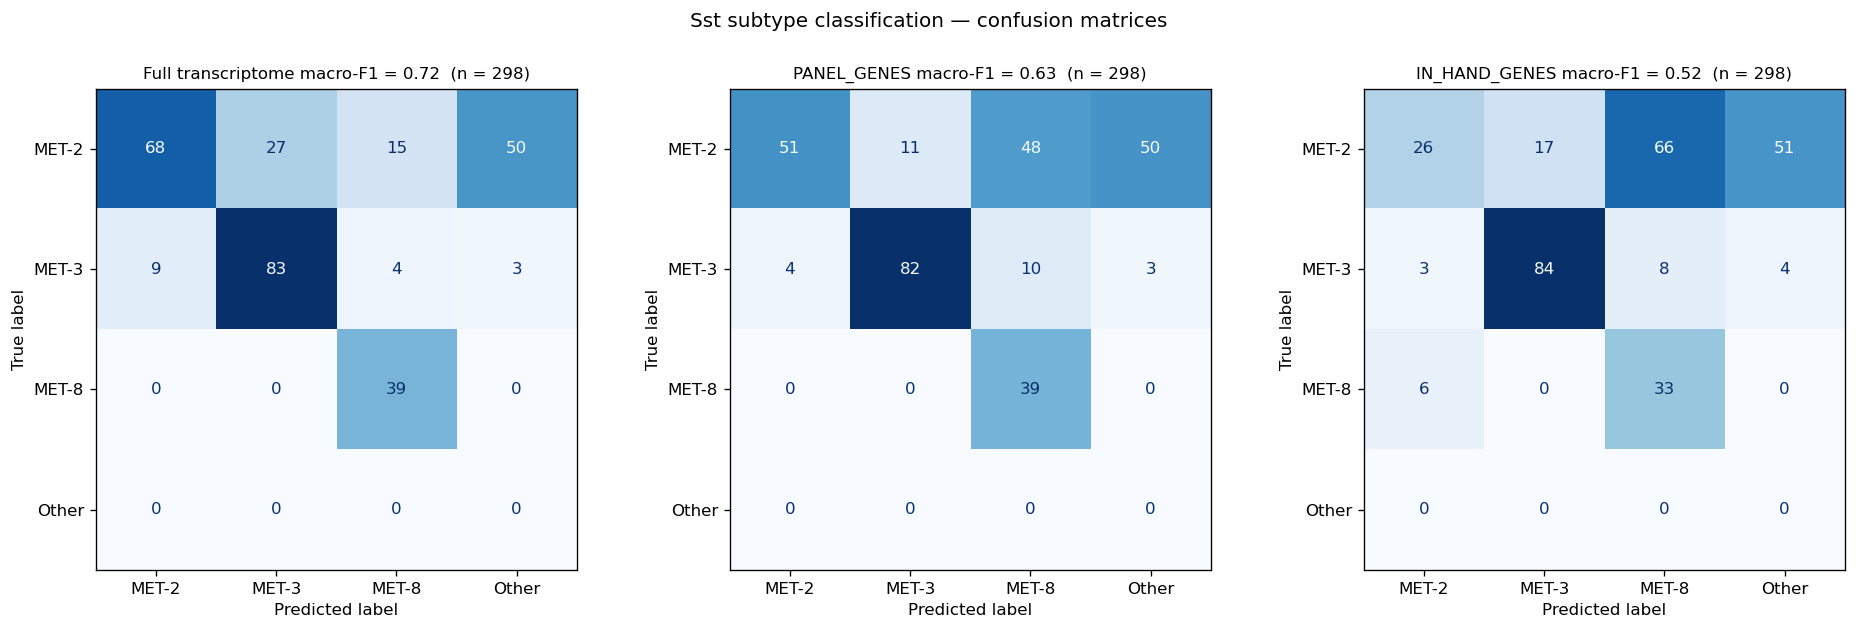

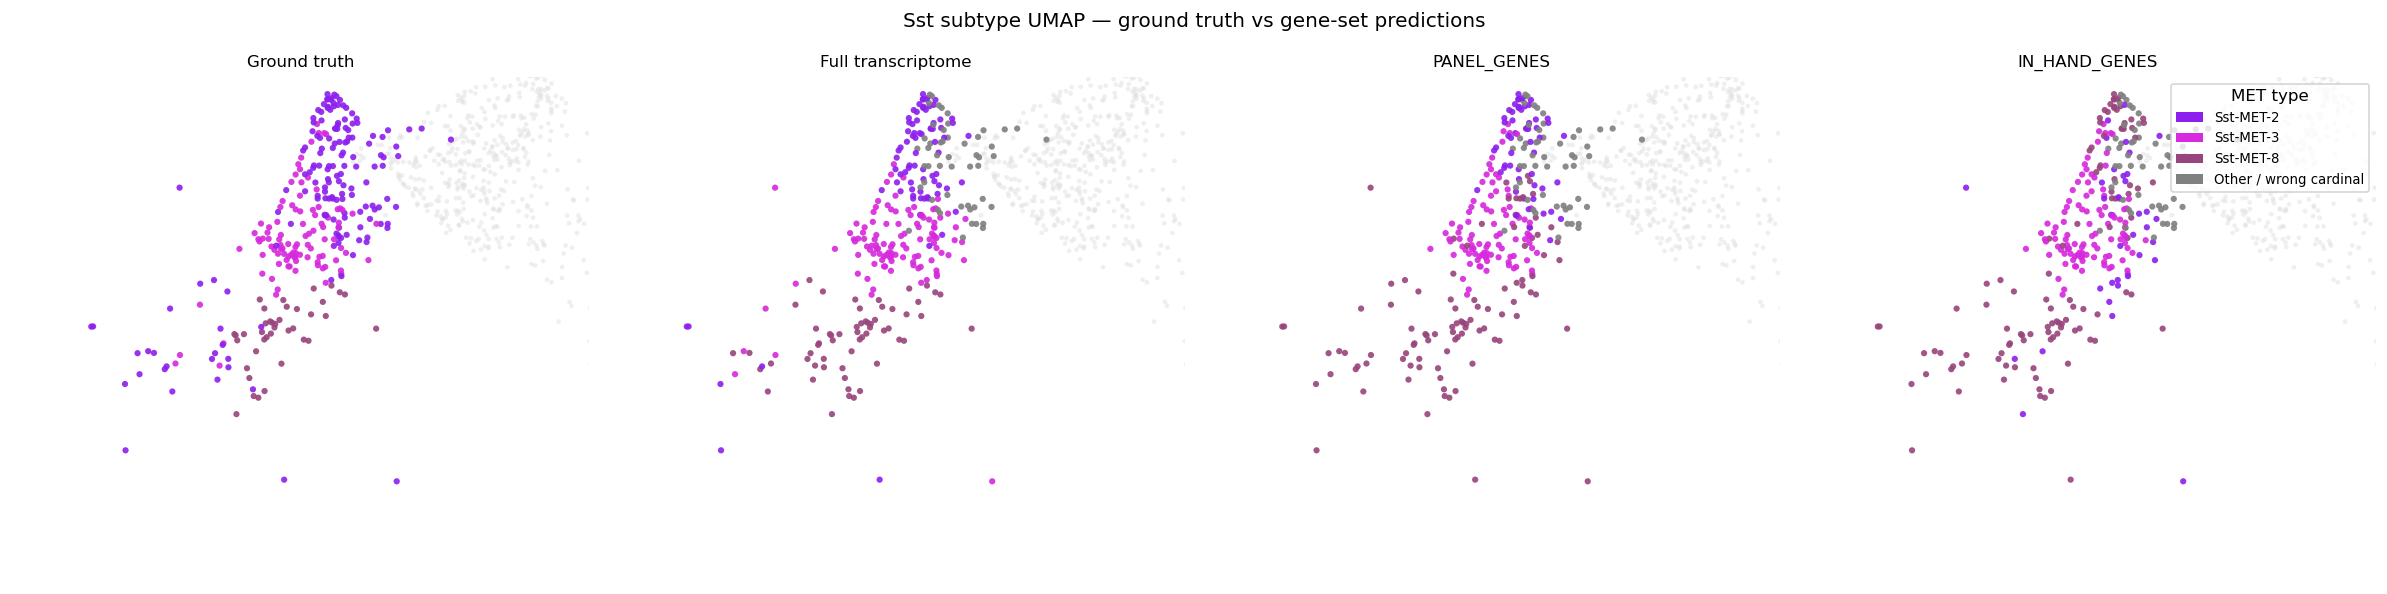

         condition  macro_F1  Sst-MET-2  Sst-MET-3  Sst-MET-8
Full transcriptome  0.724074      0.574      0.794      0.804
       PANEL_GENES  0.634038      0.474      0.854      0.574
     IN_HAND_GENES  0.519574      0.267      0.840      0.452


In [247]:
## Sst subtype classification: full transcriptome vs PANEL_GENES vs IN_HAND_GENES
# PANEL_GENES = ['Sst', 'Pvalb', 'Vip', 'Lamp5','Gad2', 'Cck', 'Chat', 'Tac1', 'Crh', 'Penk',
#             'Pdyn', 'Calb2', 'Reln', 'Tac2', 'Calb1', 'Mme', 'Ndnf', 'Hpse', 'Pthlh', 'Npy']
PANEL_GENES = ['Sst','Pvalb', 'Vip', 'Lamp5','Sncg','Calb2','Penk','Tac1'] 

# IN_HAND_GENES = ['Sst', 'Pvalb', 'Vip', 'Lamp5','Chat', 'Tac1', 'Crh', 'Gad2', 'Penk', 'Pdyn','Calb2', 'Cck'] 
IN_HAND_GENES = ['Sst','Pvalb', 'Vip', 'Lamp5','Sncg','Calb2','Penk'] 


# Evaluate on cells whose ground-truth label is one of the three Sst METs of interest
SST_METS = ['Sst-MET-2', 'Sst-MET-3', 'Sst-MET-8']

# --- gene column index sets for each condition ---
panel_cols   = [shared_gene_pos[g] for g in PANEL_GENES   if g in shared_gene_pos]
in_hand_cols = [shared_gene_pos[g] for g in IN_HAND_GENES if g in shared_gene_pos]
print(f"Genes available — Full shared: {X_log.shape[1]}, PANEL: {len(panel_cols)}, IN_HAND: {len(in_hand_cols)}")
missing_panel   = [g for g in PANEL_GENES   if g not in shared_gene_pos]
missing_in_hand = [g for g in IN_HAND_GENES if g not in shared_gene_pos]
if missing_panel:   print(f"  PANEL not in shared space: {missing_panel}")
if missing_in_hand: print(f"  IN_HAND not in shared space: {missing_in_hand}")

# --- run three assignments ---
pred_full    = assign_met_type(X_log, ref_log, pred_class, subclass_to_mets, met_idx, gene_cols=None)
pred_panel   = assign_met_type(X_log, ref_log, pred_class, subclass_to_mets, met_idx, gene_cols=panel_cols)
pred_in_hand = assign_met_type(X_log, ref_log, pred_class, subclass_to_mets, met_idx, gene_cols=in_hand_cols)

# --- restrict to true Sst-MET-2/3/8 cells ---
sst_mask = np.isin(gt_aligned, SST_METS)
sst_idx  = np.where(sst_mask)[0]
gt_sst   = gt_aligned[sst_mask]

# non-Sst-MET predictions collapsed to 'Other' (wrong cardinal class escaped)
def _sst_pred(pred_arr):
    p = pred_arr[sst_mask]
    return np.where(np.isin(p, SST_METS), p, 'Other')

pred_full_sst    = _sst_pred(pred_full)
pred_panel_sst   = _sst_pred(pred_panel)
pred_in_hand_sst = _sst_pred(pred_in_hand)

cm_labels    = SST_METS + ['Other']
cm_disp_labs = [m.replace('Sst-', '') for m in cm_labels]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

conditions = [
    ('Full transcriptome', pred_full_sst),
    ('PANEL_GENES',        pred_panel_sst),
    ('IN_HAND_GENES',      pred_in_hand_sst),
]

# --- Figure 1: confusion matrices ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pred) in zip(axes, conditions):
    cm = confusion_matrix(gt_sst, pred, labels=cm_labels)
    f1 = f1_score(gt_sst, pred, labels=SST_METS, average='macro', zero_division=0)
    disp = ConfusionMatrixDisplay(cm, display_labels=cm_disp_labs)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} macro-F1 = {f1:.2f}  (n = {sst_mask.sum()})', fontsize=10)
fig.suptitle('Sst subtype classification — confusion matrices', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 2: UMAP ---
umap_xy  = adata_l23_inh.obsm['X_umap']
bg_col   = (0.88, 0.88, 0.88)
other_col = (0.50, 0.50, 0.50)

def _umap_sst(ax, labels_arr, title):
    ax.scatter(umap_xy[:, 0], umap_xy[:, 1],
               c=[bg_col]*len(umap_xy), s=8, alpha=0.5, linewidths=0, rasterized=True)
    colors = [met_color.get(m, other_col) for m in labels_arr]
    ax.scatter(umap_xy[sst_idx, 0], umap_xy[sst_idx, 1],
               c=colors, s=14, alpha=0.9, linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=10)
    ax.axis('off') 
    ax.set_xlim([-8,5])
    ax.set_ylim([6,16])


umap_conditions = [('Ground truth', gt_sst)] + [(name, pred) for name, pred in conditions]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, lab) in zip(axes, umap_conditions):
    _umap_sst(ax, lab, name)

from matplotlib.patches import Patch
legend_elements  = [Patch(facecolor=met_color[m], label=m) for m in SST_METS]
legend_elements += [Patch(facecolor=other_col, label='Other / wrong cardinal')]
axes[-1].legend(handles=legend_elements, fontsize=8, loc='upper right',
                framealpha=0.8, title='MET type')
fig.suptitle('Sst subtype UMAP — ground truth vs gene-set predictions', fontsize=12)
plt.tight_layout()
plt.show()

# --- summary table ---
rows = []
for name, pred in conditions:
    f1 = f1_score(gt_sst, pred, labels=SST_METS, average='macro', zero_division=0)
    per_class = f1_score(gt_sst, pred, labels=SST_METS, average=None, zero_division=0)
    rows.append({'condition': name, 'macro_F1': f1,
                 **{m: round(v,3) for m, v in zip(SST_METS, per_class)}})
print(pd.DataFrame(rows).to_string(index=False))


Tac1    : threshold=0.01  21.9% cells positive
Calb2   : threshold=0.01  42.9% cells positive
Hpse    : threshold=0.01  2.4% cells positive


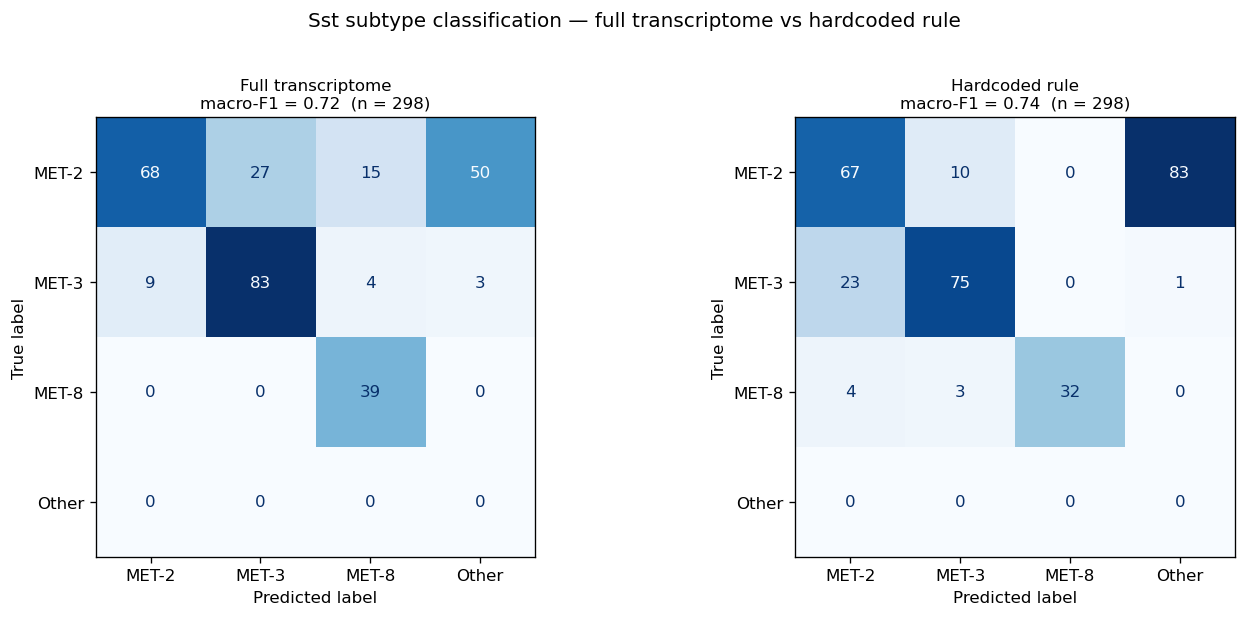

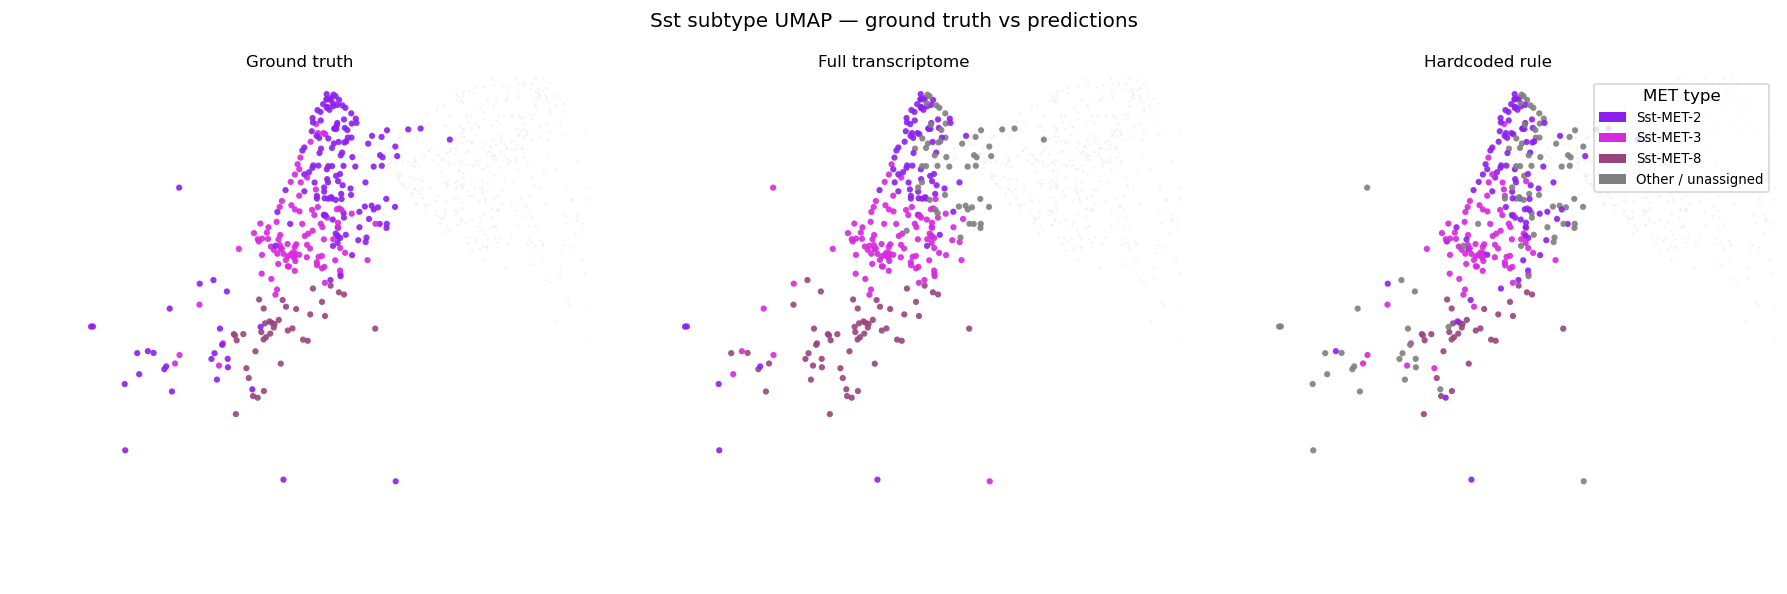

Full transcriptome      macro-F1=0.724  Sst-MET-2=0.574  Sst-MET-3=0.794  Sst-MET-8=0.804
Hardcoded rule          macro-F1=0.744  Sst-MET-2=0.528  Sst-MET-3=0.802  Sst-MET-8=0.901


In [251]:
## Hardcoded Sst subtype rule: Tac1→MET-2, Calb2→MET-3, Hpse→MET-8
# Rule (applied to Sst-cardinal cells):
#   Sst+ & Tac1+  → Sst-MET-2   (priority 1)
#   Sst+ & Calb2+ → Sst-MET-3   (priority 2)
#   Sst+ & Hpse+  → Sst-MET-8   (priority 3)
#   No secondary marker fires    → Other

SST_METS = ['Sst-MET-2', 'Sst-MET-3', 'Sst-MET-8']

RULE_GENES  = ['Tac1', 'Calb2', 'Hpse']
RULE_LABELS = ['Sst-MET-2', 'Sst-MET-3', 'Sst-MET-8']

# --- binarize rule genes (fit GMM if not already in gmm_thresholds) ---
rule_thresholds = {}
for gene in RULE_GENES:
    if gene in gmm_thresholds:
        rule_thresholds[gene] = gmm_thresholds[gene]
        continue
    if gene not in shared_gene_pos:
        print(f'WARNING: {gene} not in shared gene space — skipping')
        continue
    vals = X_log[:, shared_gene_pos[gene]].reshape(-1, 1)
    gm   = GaussianMixture(n_components=2, random_state=42).fit(vals)
    order   = np.argsort(gm.means_.ravel())
    hi_idx  = int(order[1])
    try:
        t = brentq(lambda x, g=gm, h=hi_idx: g.predict_proba([[x]])[0][h] - THRESHOLD_PROB,
                   0.0, float(vals.max()) + 2.0)
    except ValueError:
        t = float(vals.mean())
        print(f'{gene}: brentq failed, using mean={t:.2f} as fallback')
    rule_thresholds[gene] = t
    pct = (X_log[:, shared_gene_pos[gene]] > t).mean() * 100
    print(f'{gene:<8s}: threshold={t:.2f}  {pct:.1f}% cells positive')

sst_thresh = gmm_thresholds['Sst']

# --- apply rules to all cells ---
n_cells   = X_log.shape[0]
pred_rule = np.full(n_cells, 'Other', dtype=object)

for gene, label in zip(RULE_GENES, RULE_LABELS):
    if gene not in rule_thresholds or gene not in shared_gene_pos:
        continue
    sst_pos  = X_log[:, shared_gene_pos['Sst']]  >= sst_thresh
    gene_pos = X_log[:, shared_gene_pos[gene]]   >= rule_thresholds[gene]
    fires    = sst_pos & gene_pos & (pred_rule == 'Other')  # priority: first match wins
    pred_rule[fires] = label

# --- evaluate on true Sst-MET-2/3/8 cells ---
sst_mask = np.isin(gt_aligned, SST_METS)
sst_idx  = np.where(sst_mask)[0]
gt_sst   = gt_aligned[sst_mask]

def _to_sst(pred_arr):
    p = pred_arr[sst_mask]
    return np.where(np.isin(p, SST_METS), p, 'Other')

pred_rule_sst = _to_sst(pred_rule)
pred_full_sst = _to_sst(pred_met_baseline)  # full-transcriptome baseline from c9d0e1f2

cm_labels    = SST_METS + ['Other']
cm_disp_labs = [m.replace('Sst-', '') for m in cm_labels]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# --- Figure 1: side-by-side confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pred) in zip(axes, [('Full transcriptome', pred_full_sst),
                                    ('Hardcoded rule', pred_rule_sst)]):
    cm = confusion_matrix(gt_sst, pred, labels=cm_labels)
    f1 = f1_score(gt_sst, pred, labels=SST_METS, average='macro', zero_division=0)
    disp = ConfusionMatrixDisplay(cm, display_labels=cm_disp_labs)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nmacro-F1 = {f1:.2f}  (n = {sst_mask.sum()})', fontsize=10)
fig.suptitle('Sst subtype classification — full transcriptome vs hardcoded rule', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 2: UMAP ---
umap_xy   = adata_l23_inh.obsm['X_umap']
bg_col    = (0.88, 0.88, 0.88)
other_col = (0.50, 0.50, 0.50)

def _umap_sst(ax, labels_arr, title):
    ax.scatter(umap_xy[:, 0], umap_xy[:, 1],
               c=[bg_col]*len(umap_xy), s=3, alpha=0.3, linewidths=0, rasterized=True)
    colors = [met_color.get(m, other_col) for m in labels_arr]
    ax.scatter(umap_xy[sst_idx, 0], umap_xy[sst_idx, 1],
               c=colors, s=14, alpha=0.9, linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    ax.set_xlim([-8,5])
    ax.set_ylim([6,16])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, lab) in zip(axes, [('Ground truth',        gt_sst),
                                   ('Full transcriptome',  pred_full_sst),
                                   ('Hardcoded rule',      pred_rule_sst)]):
    _umap_sst(ax, lab, name)

from matplotlib.patches import Patch
leg = [Patch(facecolor=met_color[m], label=m) for m in SST_METS]
leg.append(Patch(facecolor=other_col, label='Other / unassigned'))
axes[-1].legend(handles=leg, fontsize=8, loc='upper right', framealpha=0.8, title='MET type')
fig.suptitle('Sst subtype UMAP — ground truth vs predictions', fontsize=12)
plt.tight_layout()
plt.show()

# --- per-class summary ---
for name, pred in [('Full transcriptome', pred_full_sst), ('Hardcoded rule', pred_rule_sst)]:
    f1 = f1_score(gt_sst, pred, labels=SST_METS, average='macro', zero_division=0)
    pc = f1_score(gt_sst, pred, labels=SST_METS, average=None, zero_division=0)
    print(f'{name:<22s}  macro-F1={f1:.3f}  ' +
          '  '.join(f'{m}={v:.3f}' for m, v in zip(SST_METS, pc)))


Tac1    : threshold=0.01  21.9% cells positive
Calb2   : threshold=0.01  42.9% cells positive
Hpse    : threshold=0.01  2.4% cells positive
Pdyn    : threshold=0.01  9.9% cells positive


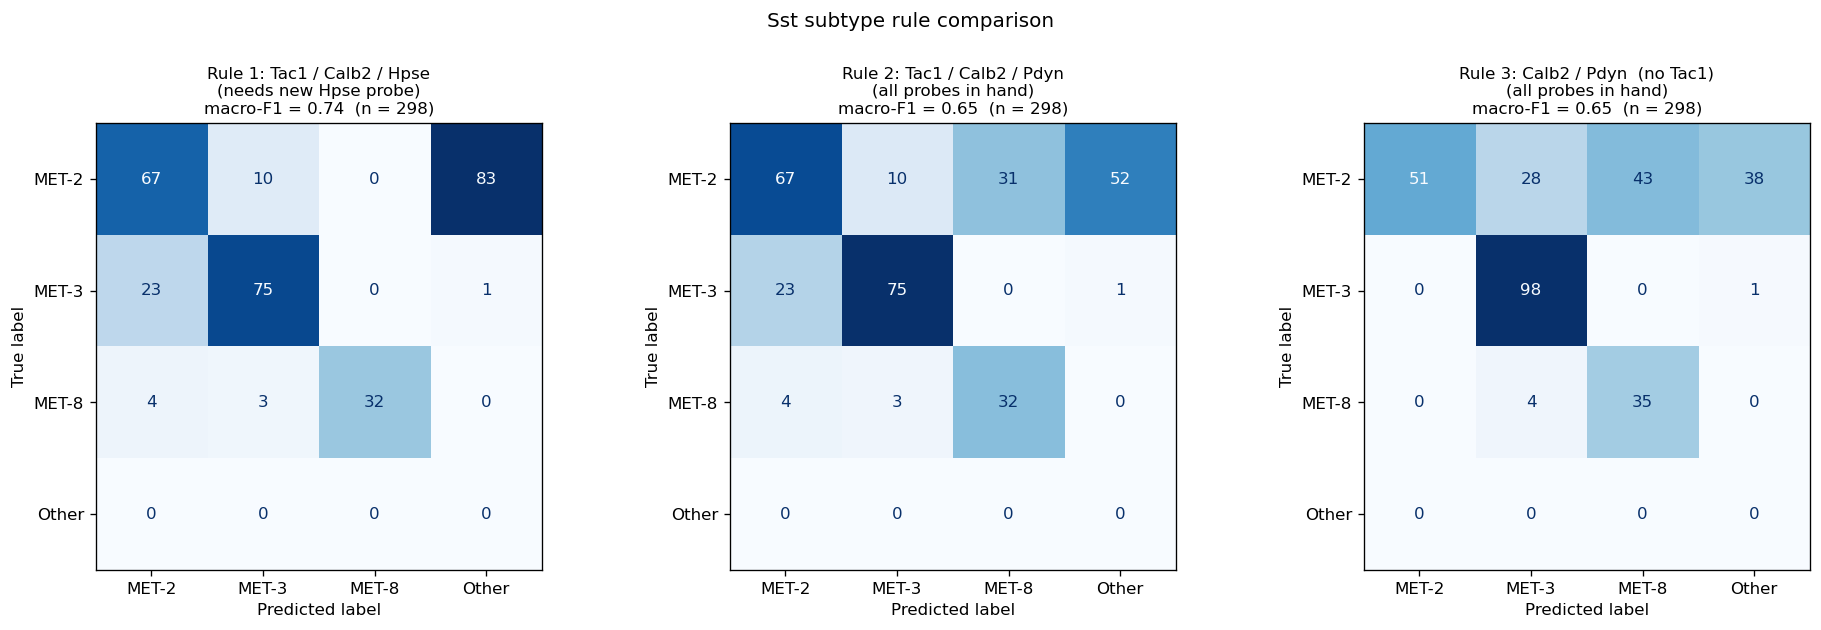

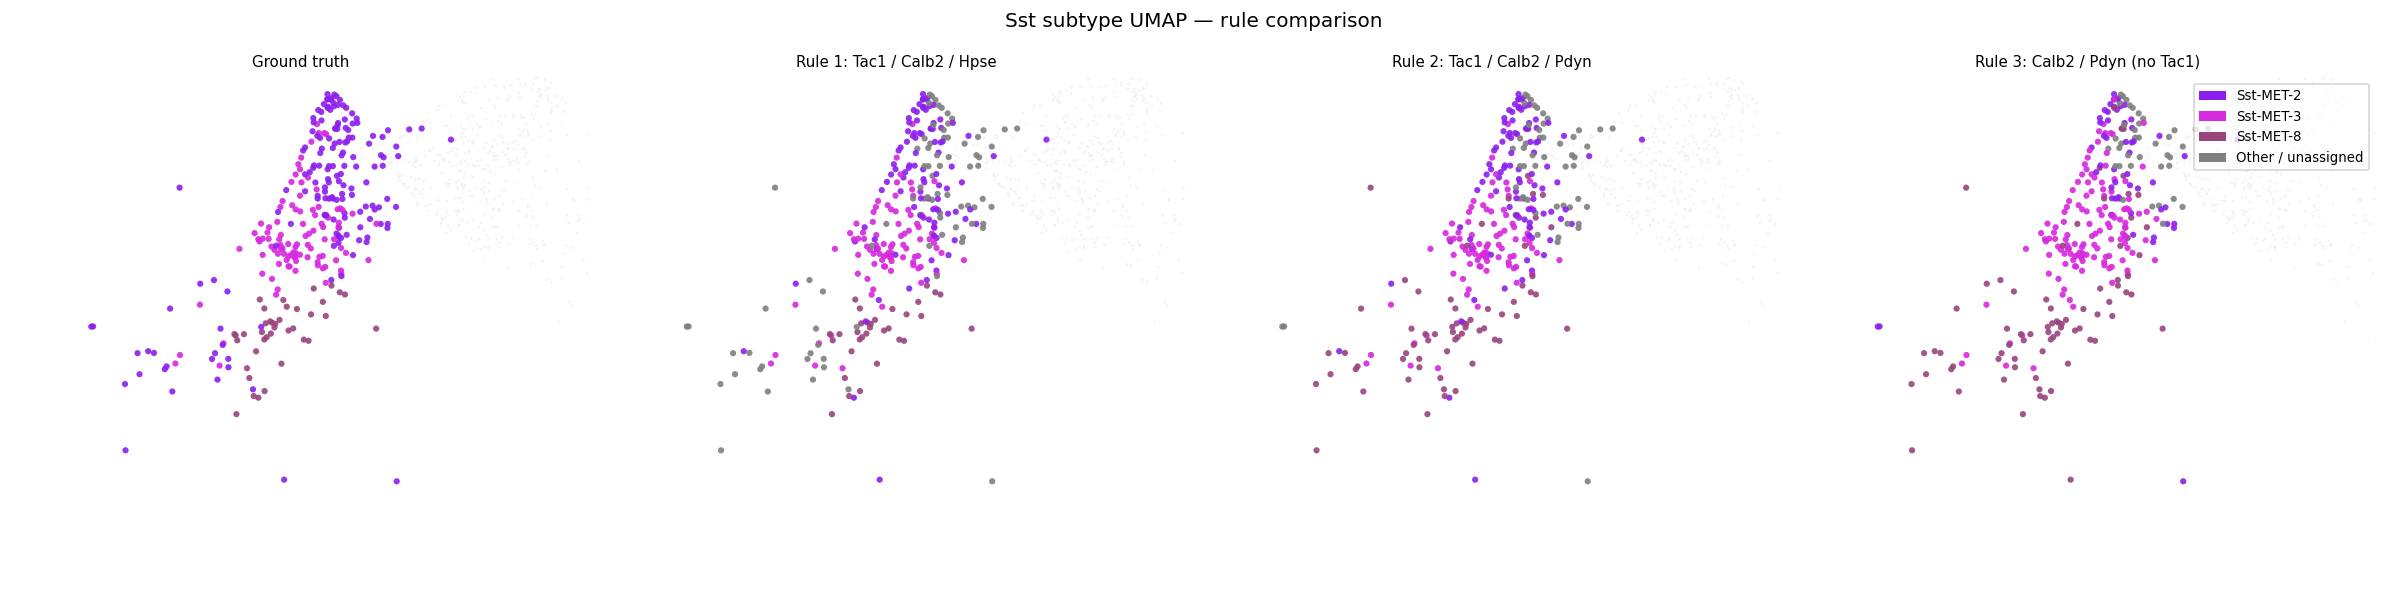

Rule 1 (Hpse)         macro-F1=0.744  Sst-MET-2=0.528  Sst-MET-3=0.802  Sst-MET-8=0.901
Rule 2 (Pdyn)         macro-F1=0.652  Sst-MET-2=0.528  Sst-MET-3=0.802  Sst-MET-8=0.627
Rule 3 (no Tac1)      macro-F1=0.646  Sst-MET-2=0.483  Sst-MET-3=0.856  Sst-MET-8=0.598


In [254]:
## Hardcoded rule comparison: Rule 1 (Hpse) vs Rule 2 (Pdyn) vs Rule 3 (no Tac1)
# Rule 1: Sst+ Tac1+          → MET-2  (priority 1)
#         Sst+ Calb2+          → MET-3  (priority 2)
#         Sst+ Hpse+           → MET-8  (priority 3)   [needs new probe]
#
# Rule 2: Sst+ Tac1+          → MET-2  (priority 1)
#         Sst+ Calb2+          → MET-3  (priority 2)
#         Sst+ Calb2- Pdyn+    → MET-8  (priority 3)   [all probes in hand]
#
# Rule 3: Sst+ Calb2- Pdyn-   → MET-2  (no Tac1 needed)
#         Sst+ Calb2+          → MET-3
#         Sst+ Calb2- Pdyn+    → MET-8  [all probes in hand]

SST_METS = ['Sst-MET-2', 'Sst-MET-3', 'Sst-MET-8']

# --- fit GMMs for any non-cardinal gene not yet thresholded ---
_extra_genes = ['Tac1', 'Calb2', 'Hpse', 'Pdyn']
rule_thresholds = dict(gmm_thresholds)

for gene in _extra_genes:
    if gene in rule_thresholds:
        continue
    if gene not in shared_gene_pos:
        print(f'WARNING: {gene} not in shared gene space')
        continue
    vals = X_log[:, shared_gene_pos[gene]].reshape(-1, 1)
    gm   = GaussianMixture(n_components=2, random_state=42).fit(vals)
    hi   = int(np.argmax(gm.means_.ravel()))
    try:
        t = brentq(lambda x, g=gm, h=hi: g.predict_proba([[x]])[0][h] - THRESHOLD_PROB,
                   0.0, float(vals.max()) + 2.0)
    except ValueError:
        t = float(vals.mean())
    rule_thresholds[gene] = t
    pct = (X_log[:, shared_gene_pos[gene]] > t).mean() * 100
    print(f'{gene:<8s}: threshold={t:.2f}  {pct:.1f}% cells positive')

def _bin(gene):
    return X_log[:, shared_gene_pos[gene]] >= rule_thresholds[gene]

sst_pos   = _bin('Sst')
tac1_pos  = _bin('Tac1')
calb2_pos = _bin('Calb2')
hpse_pos  = _bin('Hpse')
pdyn_pos  = _bin('Pdyn')

n = X_log.shape[0]

# Rule 1 (Hpse, priority chain)
pred_r1 = np.full(n, 'Other', dtype=object)
pred_r1[sst_pos & tac1_pos]                          = 'Sst-MET-2'
pred_r1[sst_pos & calb2_pos & (pred_r1 == 'Other')]  = 'Sst-MET-3'
pred_r1[sst_pos & hpse_pos  & (pred_r1 == 'Other')]  = 'Sst-MET-8'

# Rule 2 (Pdyn, explicit Calb2-)
pred_r2 = np.full(n, 'Other', dtype=object)
pred_r2[sst_pos & tac1_pos]                                     = 'Sst-MET-2'
pred_r2[sst_pos & calb2_pos & (pred_r2 == 'Other')]             = 'Sst-MET-3'
pred_r2[sst_pos & ~calb2_pos & pdyn_pos & (pred_r2 == 'Other')] = 'Sst-MET-8'

# Rule 3 (no Tac1 — mutually exclusive by construction)
pred_r3 = np.full(n, 'Other', dtype=object)
pred_r3[sst_pos & calb2_pos]                = 'Sst-MET-3'
pred_r3[sst_pos & ~calb2_pos & pdyn_pos]    = 'Sst-MET-8'
pred_r3[sst_pos & ~calb2_pos & ~pdyn_pos]   = 'Sst-MET-2'

# --- restrict to true Sst-MET-2/3/8 cells ---
sst_mask = np.isin(gt_aligned, SST_METS)
sst_idx  = np.where(sst_mask)[0]
gt_sst   = gt_aligned[sst_mask]

def _clip(pred_arr):
    p = pred_arr[sst_mask]
    return np.where(np.isin(p, SST_METS), p, 'Other')

pred_r1_sst = _clip(pred_r1)
pred_r2_sst = _clip(pred_r2)
pred_r3_sst = _clip(pred_r3)

cm_labels    = SST_METS + ['Other']
cm_disp_labs = [m.replace('Sst-', '') for m in cm_labels]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

rule_preds = [
    ('Rule 1: Tac1 / Calb2 / Hpse\n(needs new Hpse probe)',        pred_r1_sst),
    ('Rule 2: Tac1 / Calb2 / Pdyn\n(all probes in hand)',          pred_r2_sst),
    ('Rule 3: Calb2 / Pdyn  (no Tac1)\n(all probes in hand)',      pred_r3_sst),
]

# --- Figure 1: confusion matrices ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pred) in zip(axes, rule_preds):
    cm = confusion_matrix(gt_sst, pred, labels=cm_labels)
    f1 = f1_score(gt_sst, pred, labels=SST_METS, average='macro', zero_division=0)
    disp = ConfusionMatrixDisplay(cm, display_labels=cm_disp_labs)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nmacro-F1 = {f1:.2f}  (n = {sst_mask.sum()})', fontsize=10)
fig.suptitle('Sst subtype rule comparison', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 2: UMAP ---
umap_xy   = adata_l23_inh.obsm['X_umap']
bg_col    = (0.88, 0.88, 0.88)
other_col = (0.50, 0.50, 0.50)

def _umap_sst(ax, labels_arr, title):
    ax.scatter(umap_xy[:, 0], umap_xy[:, 1],
               c=[bg_col]*len(umap_xy), s=3, alpha=0.3, linewidths=0, rasterized=True)
    colors = [met_color.get(m, other_col) for m in labels_arr]
    ax.scatter(umap_xy[sst_idx, 0], umap_xy[sst_idx, 1],
               c=colors, s=14, alpha=0.9, linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    ax.set_xlim([-8, 5])
    ax.set_ylim([6, 16])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
_umap_sst(axes[0], gt_sst,      'Ground truth')
_umap_sst(axes[1], pred_r1_sst, 'Rule 1: Tac1 / Calb2 / Hpse')
_umap_sst(axes[2], pred_r2_sst, 'Rule 2: Tac1 / Calb2 / Pdyn')
_umap_sst(axes[3], pred_r3_sst, 'Rule 3: Calb2 / Pdyn (no Tac1)')

from matplotlib.patches import Patch
leg = [Patch(facecolor=met_color[m], label=m) for m in SST_METS]
leg.append(Patch(facecolor=other_col, label='Other / unassigned'))
axes[-1].legend(handles=leg, fontsize=8, loc='upper right', framealpha=0.8)
fig.suptitle('Sst subtype UMAP — rule comparison', fontsize=12)
plt.tight_layout()
plt.show()

# --- summary ---
for name, pred in [('Rule 1 (Hpse)',      pred_r1_sst),
                   ('Rule 2 (Pdyn)',       pred_r2_sst),
                   ('Rule 3 (no Tac1)',    pred_r3_sst)]:
    f1  = f1_score(gt_sst, pred, labels=SST_METS, average='macro', zero_division=0)
    pcs = f1_score(gt_sst, pred, labels=SST_METS, average=None, zero_division=0)
    print(f'{name:<20s}  macro-F1={f1:.3f}  ' +
          '  '.join(f'{m}={v:.3f}' for m, v in zip(SST_METS, pcs)))


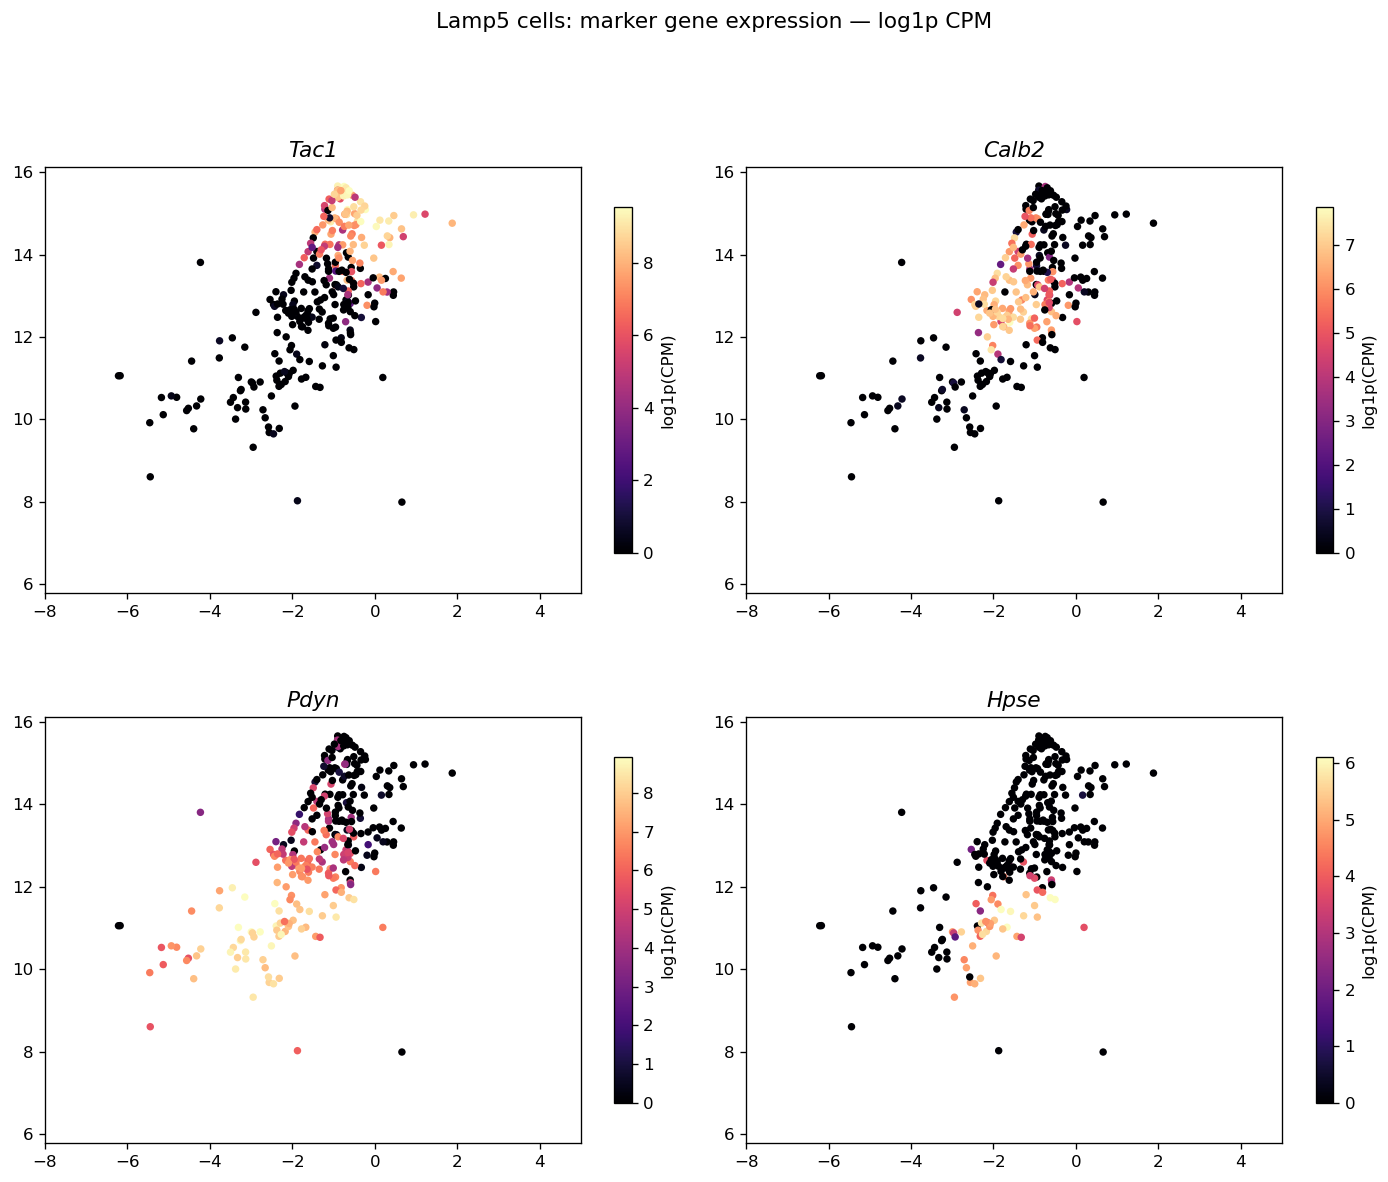

In [250]:
## Lamp5 subtype marker expression on UMAP

LAMP5_MARKERS = ['Tac1','Calb2','Pdyn','Hpse']

lamp5_mask = (adata_l23_inh.obs['subclass'] == 'Sst').values
umap_lamp5 = adata_l23_inh.obsm['X_umap'][lamp5_mask]

gene_expr = {}
for g in LAMP5_MARKERS:
    entrez = sym_to_entrez.get(g)
    if entrez is None:
        print(f'Warning: {g} not found in Tasic gene set')
        continue
    col = adata_l23_inh.var_names.get_loc(entrez)
    raw = adata_l23_inh.layers['counts'][lamp5_mask, col]
    if hasattr(raw, 'toarray'):
        raw = raw.toarray().ravel()
    else:
        raw = np.asarray(raw).ravel()
    gene_expr[g] = np.log1p(raw / cell_total[lamp5_mask].squeeze() * 1e6)

rng = np.random.default_rng(42)
idx = rng.permutation(lamp5_mask.sum())

n_cols = 2
n_rows = int(np.ceil(len(gene_expr) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

for ax, g in zip(np.array(axes).ravel(), gene_expr):
    expr = gene_expr[g][idx]
    vmax = float(np.percentile(expr, 99)) or 1.0
    sc = ax.scatter(
        umap_lamp5[idx, 0], umap_lamp5[idx, 1],
        c=expr, cmap='magma', s=20, linewidths=0,
        vmin=0, vmax=vmax, rasterized=True,
    )
    ax.set_title(g, fontsize=13, style='italic')
    ax.set_aspect('equal')
    ax.set_xlim([-8,5])
    # ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    # for spine in ax.spines.values():
    #     spine.set_visible(False)
    plt.colorbar(sc, ax=ax, shrink=0.6, label='log1p(CPM)')

# Hide any unused axes
for ax in np.array(axes).ravel()[len(gene_expr):]:
    ax.set_visible(False)

fig.suptitle('Lamp5 cells: marker gene expression — log1p CPM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


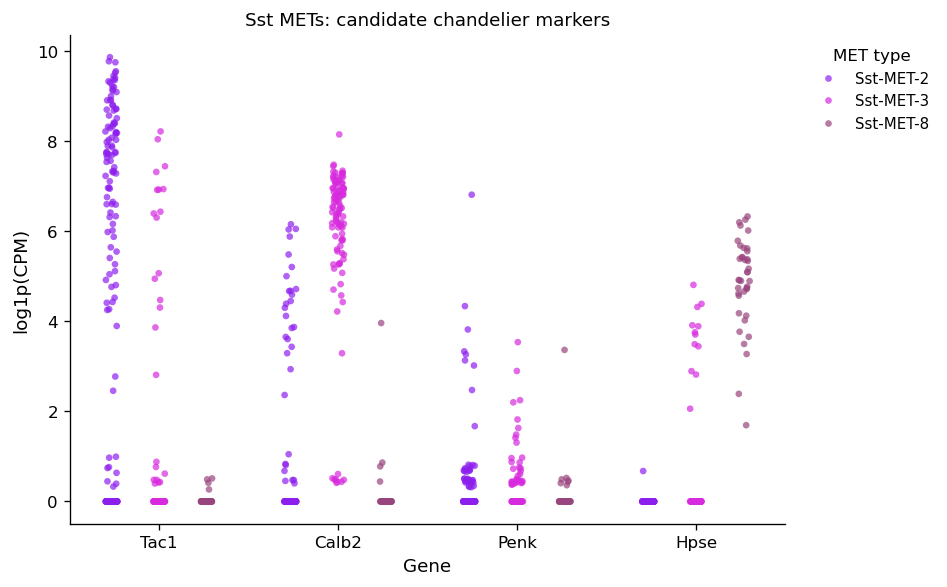

In [241]:
## Stripplot: Pvalb-MET-4 vs Pvalb-MET-5 candidate markers

PV_MARKERS = ['Tac1','Calb2','Penk','Hpse']
PV_METS    = ['Sst-MET-2', 'Sst-MET-3', 'Sst-MET-8']

pv_mask   = np.isin(gt_aligned, PV_METS)
pv_idx    = np.where(pv_mask)[0]
pv_labels = gt_aligned[pv_idx]

rows = []
for gene in PV_MARKERS:
    if gene not in shared_gene_pos:
        print(f'WARNING: {gene} not in shared genes')
        continue
    expr = X_log[pv_idx, shared_gene_pos[gene]]
    for val, met in zip(expr, pv_labels):
        rows.append({'gene': gene, 'log1p_CPM': val, 'MET type': met})

df_pv = pd.DataFrame(rows)
palette = {m: tuple(met_color[m]) for m in SST_METS }

fig, ax = plt.subplots(figsize=(8, 5))
sns.stripplot(
    data=df_pv, x='gene', y='log1p_CPM', hue='MET type',
    hue_order=SST_METS, palette=palette,
    dodge=True, size=4, jitter=True, alpha=0.7, ax=ax,
)
ax.set_xlabel('Gene', fontsize=11)
ax.set_ylabel('log1p(CPM)', fontsize=11)
ax.set_title('Sst METs: candidate chandelier markers', fontsize=11)
ax.legend(title='MET type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


### Vip subtypes

Genes available — Full shared: 45768, PANEL: 20, IN_HAND: 11


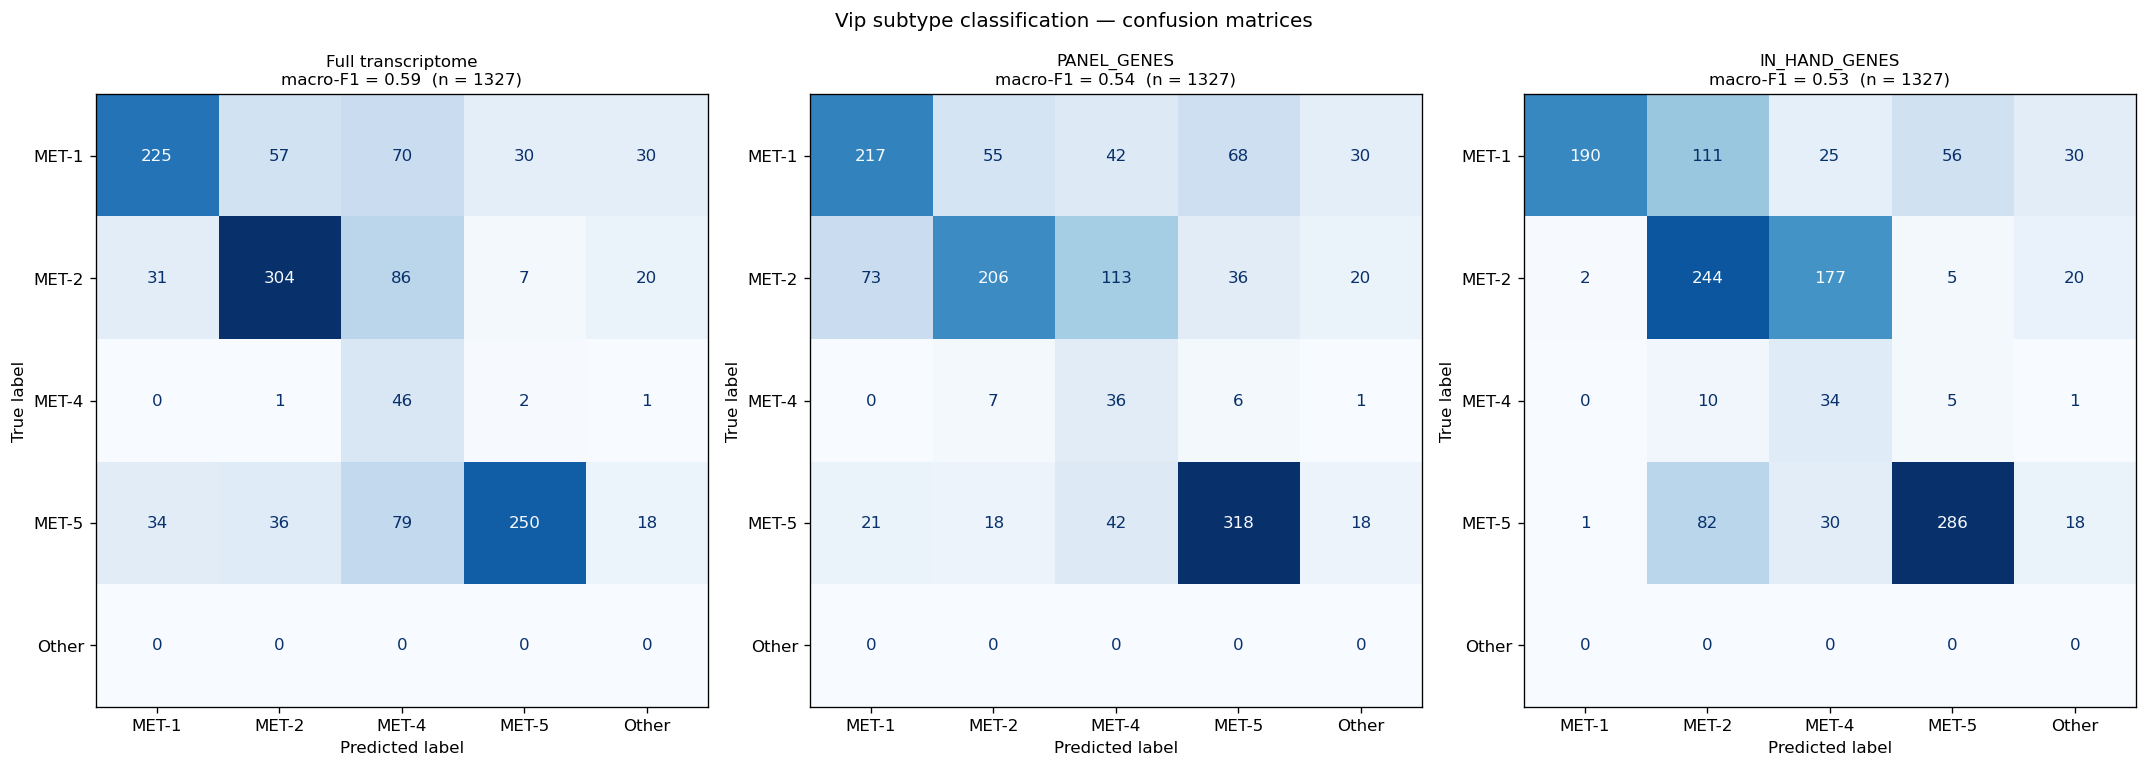

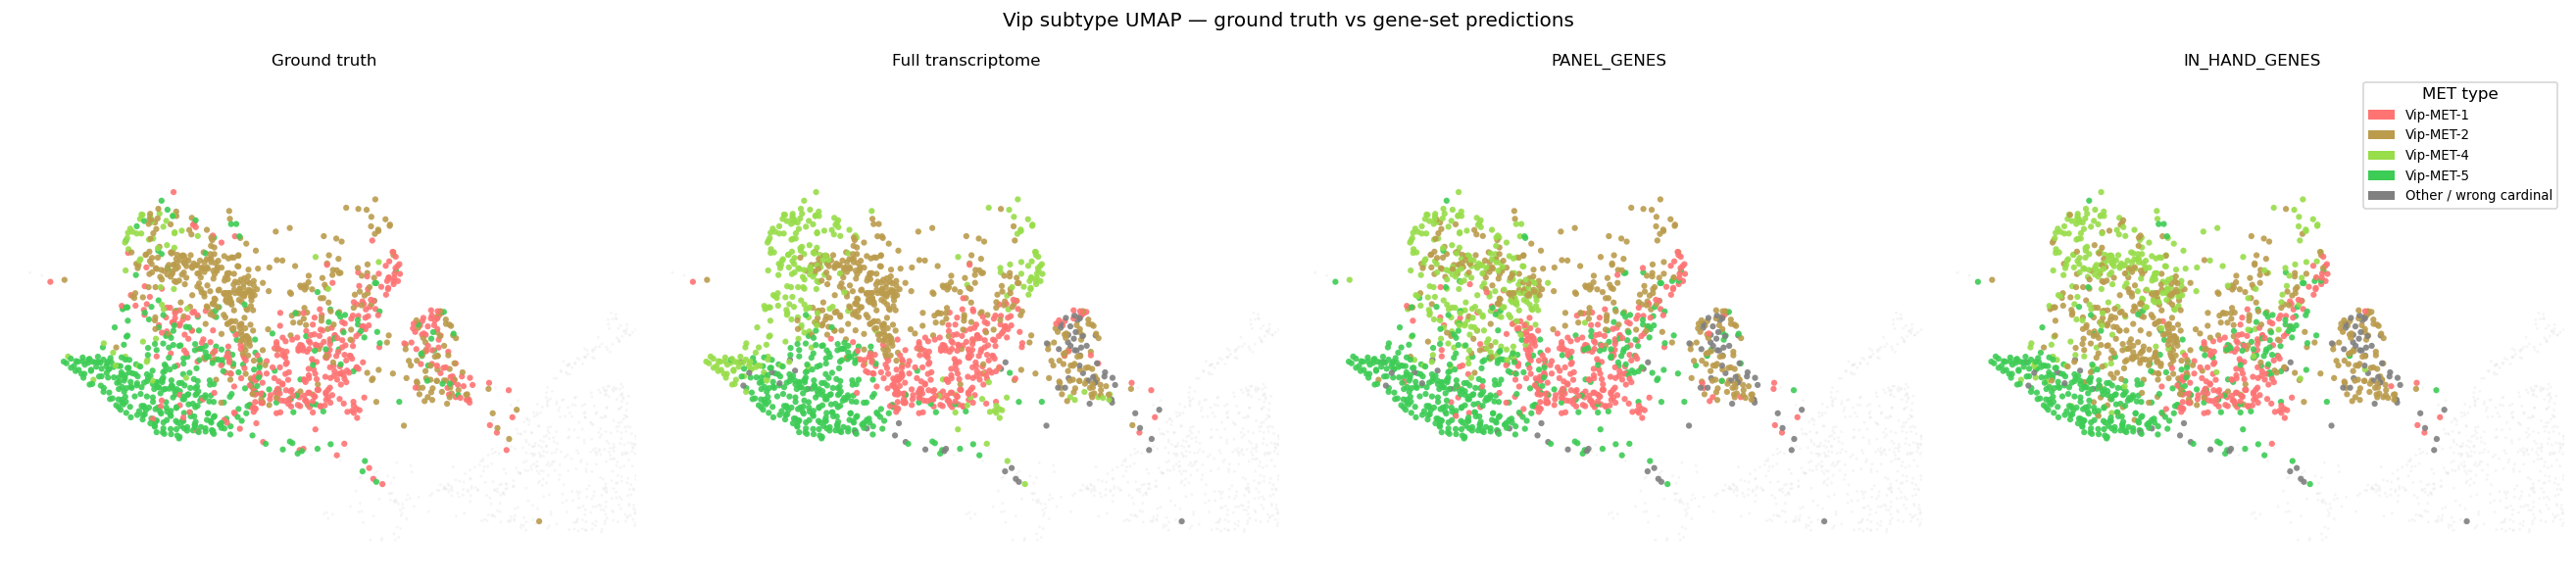

         condition  macro_F1  Vip-MET-1  Vip-MET-2  Vip-MET-4  Vip-MET-5
Full transcriptome     0.586      0.641      0.719      0.278      0.708
       PANEL_GENES     0.542      0.600      0.561      0.254      0.753
     IN_HAND_GENES     0.533      0.628      0.545      0.215      0.744


In [ ]:
## Vip subtype classification: full transcriptome vs PANEL_GENES vs IN_HAND_GENES
# Evaluate on cells whose ground-truth label is one of the four Vip METs of interest
VIP_METS = ['Vip-MET-1', 'Vip-MET-2', 'Vip-MET-4', 'Vip-MET-5']

PANEL_GENES   = ['Sst', 'Pvalb', 'Vip', 'Lamp5', 'Gad2', 'Cck', 'Chat', 'Tac1', 'Crh', 'Penk',
                 'Pdyn', 'Calb2', 'Reln', 'Tac2', 'Calb1', 'Mme', 'Ndnf', 'Hpse', 'Pthlh', 'Npy'] 

IN_HAND_GENES = ['Sst', 'Pvalb', 'Vip', 'Lamp5','Sncg','Penk', 'Pdyn','Calb2','Syndig1','Npy','Cck'] # ,'Ptprt']

# 'Ptprt' might be helpful

# --- gene column index sets ---
panel_cols   = [shared_gene_pos[g] for g in PANEL_GENES   if g in shared_gene_pos]
in_hand_cols = [shared_gene_pos[g] for g in IN_HAND_GENES if g in shared_gene_pos]
print(f'Genes available — Full shared: {X_log.shape[1]}, PANEL: {len(panel_cols)}, IN_HAND: {len(in_hand_cols)}')
missing_panel   = [g for g in PANEL_GENES   if g not in shared_gene_pos]
missing_in_hand = [g for g in IN_HAND_GENES if g not in shared_gene_pos]
if missing_panel:   print(f'  PANEL not in shared space: {missing_panel}')
if missing_in_hand: print(f'  IN_HAND not in shared space: {missing_in_hand}')

# --- run three assignments ---
pred_full    = assign_met_type(X_log, ref_log, pred_class, subclass_to_mets, met_idx, gene_cols=None)
pred_panel   = assign_met_type(X_log, ref_log, pred_class, subclass_to_mets, met_idx, gene_cols=panel_cols)
pred_in_hand = assign_met_type(X_log, ref_log, pred_class, subclass_to_mets, met_idx, gene_cols=in_hand_cols)

# --- restrict to true Vip-MET-1/2/4/5 cells ---
vip_mask = np.isin(gt_aligned, VIP_METS)
vip_idx  = np.where(vip_mask)[0]
gt_vip   = gt_aligned[vip_mask]

def _vip_pred(pred_arr):
    p = pred_arr[vip_mask]
    return np.where(np.isin(p, VIP_METS), p, 'Other')

pred_full_vip    = _vip_pred(pred_full)
pred_panel_vip   = _vip_pred(pred_panel)
pred_in_hand_vip = _vip_pred(pred_in_hand)

cm_labels    = VIP_METS + ['Other']
cm_disp_labs = [m.replace('Vip-', '') for m in cm_labels]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

conditions = [
    ('Full transcriptome', pred_full_vip),
    ('PANEL_GENES',        pred_panel_vip),
    ('IN_HAND_GENES',      pred_in_hand_vip),
]

# --- Figure 1: confusion matrices ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, pred) in zip(axes, conditions):
    cm = confusion_matrix(gt_vip, pred, labels=cm_labels)
    f1 = f1_score(gt_vip, pred, labels=VIP_METS, average='macro', zero_division=0)
    disp = ConfusionMatrixDisplay(cm, display_labels=cm_disp_labs)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nmacro-F1 = {f1:.2f}  (n = {vip_mask.sum()})', fontsize=10)
fig.suptitle('Vip subtype classification — confusion matrices', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --- Figure 2: UMAP ---
umap_xy   = adata_l23_inh.obsm['X_umap']
bg_col    = (0.88, 0.88, 0.88)
other_col = (0.50, 0.50, 0.50)

def _umap_vip(ax, labels_arr, title):
    ax.scatter(umap_xy[:, 0], umap_xy[:, 1],
               c=[bg_col]*len(umap_xy), s=3, alpha=0.3, linewidths=0, rasterized=True)
    colors = [met_color.get(m, other_col) for m in labels_arr]
    ax.scatter(umap_xy[vip_idx, 0], umap_xy[vip_idx, 1],
               c=colors, s=14, alpha=0.9, linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=10)
    ax.set_ylim([-8,5])
    ax.set_xlim([-10,5])
    ax.axis('off')

umap_conditions = [('Ground truth', gt_vip)] + [(name, pred) for name, pred in conditions]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, lab) in zip(axes, umap_conditions):
    _umap_vip(ax, lab, name)

from matplotlib.patches import Patch
leg  = [Patch(facecolor=met_color[m], label=m) for m in VIP_METS]
leg += [Patch(facecolor=other_col, label='Other / wrong cardinal')]
axes[-1].legend(handles=leg, fontsize=8, loc='upper right', framealpha=0.8, title='MET type')
fig.suptitle('Vip subtype UMAP — ground truth vs gene-set predictions', fontsize=12)
plt.tight_layout()
plt.show()

# --- summary table ---
rows = []
for name, pred in conditions:
    f1  = f1_score(gt_vip, pred, labels=VIP_METS, average='macro', zero_division=0)
    pcs = f1_score(gt_vip, pred, labels=VIP_METS, average=None, zero_division=0)
    rows.append({'condition': name, 'macro_F1': round(f1, 3),
                 **{m: round(v, 3) for m, v in zip(VIP_METS, pcs)}})
print(pd.DataFrame(rows).to_string(index=False))


#### Marker testing 

In [ ]:
PANEL_GENES = ['Sst', 'Pvalb', 'Vip', 'Lamp5','Gad2', 'Cck', 'Chat', 'Tac1', 'Crh', 'Penk',
            'Pdyn', 'Calb2', 'Reln', 'Tac2', 'Calb1', 'Mme', 'Ndnf', 'Hpse', 'Pthlh', 'Npy']

IN_HAND_GENES = ['Sst', 'Pvalb', 'Vip', 'Lamp5','Chat', 'Tac1', 'Crh', 'Gad2', 'Penk', 'Pdyn',
                'Calb2', 'Cck']

In [ ]:
# Great. Let's now see how well we do with 1) restricting to only the 20 genes in our collaborator's panel and 2) restricting to only those genes in our collaborator's panel that we already have probes for. 

# 1. First, add one more hardcoded rule to the 

# 1. Repeat the two-step MET-type prediction procedure
# 2. 

Key questions:
- [x] Continuous lamp5 variation 
    - Npy and Ndnf look best in continuous space
    - Dock4 and Lsp1 are discrete, but pretty incomplete coverage
- [x] Pvalb chandelier cell differentiation
    - Pvalb+ Syndig1- looks very nice, Syndig1 is validated by allen
- [x] For Sncg, do we need Sncg or are we good w/ VIP+/CCK+/PV-
    - answer: addition of only Sncg + Penk is nicest
- [x] What is minimal set of differentiators for SST MET1-3,8
    - no need to get Hpse as we can do basically just as well w Pdyn at catching the tail
    - we can even do ok with just Calb2 and Pdyn using 'rule 3' 
        - SST+ Calb2- Pdyn- -> MET-2
        - SST+ Calb2+ -> MET-3 
        - SST+ Calb2- Pdyn+ --> MET-8
- [ ] What is minimal set of differentiators for VIP MET1,2,4,5